In [1]:
import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

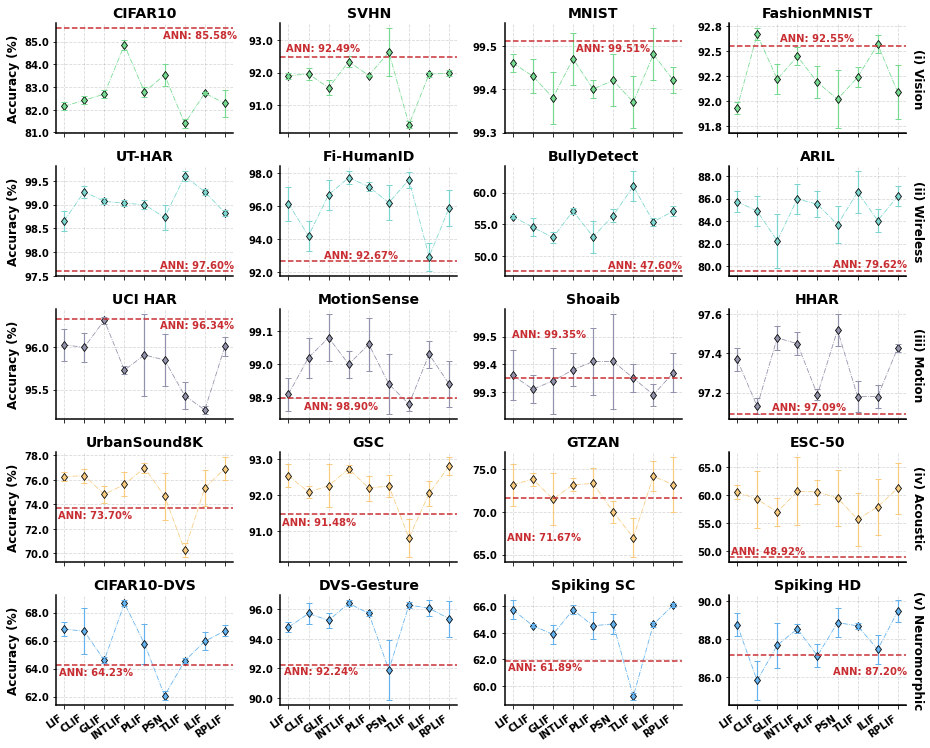

In [2]:
fig, axs = plt.subplots(5, 4, figsize=(13, 10.5))
categories = ['ANN', 'LIF', 'CLIF', 'GLIF', 'INTLIF', 'PLIF', 'PSN', 'TLIF', 'ILIF', 'RPLIF']
x = np.arange(len(categories))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
modality_colors = ['#76da91', '#f8cb7f', '#9192ab', '#7cd6cf', '#63b2ee'] # ['#002c53', '#007f54', '#0c84c6', '#2455a4', '#625ba1']
for i in range(5):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
        
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        # axs[i].set_yticks([])
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # 设置x label，只有最后一层显示
        axs[i][j].set_xticks(x[1:])
        if i == 4:
            axs[i][j].set_xticklabels(categories[1:], rotation=35, ha='right')
            # for idx, tick in enumerate(axs[i][j].get_xticklabels()):
            #     if idx == 0:
            #         tick.set_color('#c82d31')
            #     else:
            #         tick.set_color('#194f97')
        else:
            axs[i][j].set_xticklabels([])

# (a) vision sensing
line_color = modality_colors[0]
# cifar10
axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
mean_accs = [85.58, 82.15, 82.42, 82.69, 84.85, 82.79, 83.53, 81.40, 82.73, 82.28]
std_accs = [0.17, 0.17, 0.18, 0.18, 0.21, 0.21, 0.50, 0.21, 0.05, 0.58]
axs[0][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][0].text(len(categories) - 0.4, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='right', va='top')

# svhn
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
mean_accs = [92.49, 91.90, 91.96, 91.53, 92.34, 91.91, 92.63, 90.40, 91.95, 91.98]
std_accs = [0.18, 0.09, 0.19, 0.23, 0.17, 0.03, 0.73, 0.11, 0.08, 0.09]
axs[0][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][1].text(len(categories[0]) - 0.3, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# mnist
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
mean_accs = [99.51, 99.46, 99.43, 99.38, 99.47, 99.40, 99.42, 99.37, 99.48, 99.42]
std_accs = [0.04, 0.02, 0.04, 0.06, 0.06, 0.02, 0.06, 0.06, 0.06, 0.03]
axs[0][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][2].text(6, mean_accs[0] - 0.005, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# fashionmnist
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)
mean_accs = [92.55, 91.93, 92.67, 92.22, 92.45, 92.19, 92.02, 92.24, 92.57, 92.09]
std_accs = [0.11, 0.06, 0.06, 0.15, 0.09, 0.16, 0.29, 0.10, 0.09, 0.27]
axs[0][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][3].text(5, mean_accs[0] + 0.03, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# (d) Acoustic Sensing
line_color = modality_colors[1]
# urbansound
axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
mean_accs = [73.70, 76.25, 76.34, 74.81, 75.62, 76.97, 74.67, 70.26, 75.34, 76.91]
std_accs = [1.18, 0.37, 0.58, 0.68, 0.98, 0.43, 1.91, 0.56, 1.47, 0.92]
axs[3][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][0].text(0.7, mean_accs[0] - 0.15, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# GSC
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
mean_accs = [91.48, 92.55, 92.09, 92.26, 92.74, 92.20, 92.26, 90.81, 92.05, 92.82]
std_accs = [0.16, 0.31, 0.17, 0.6, 0.11, 0.35, 0.30, 0.54, 0.35, 0.24]
axs[3][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][1].text(0.7, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# GTZAN
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
mean_accs = [71.67, 73.17, 73.83, 71.50, 73.17, 73.33, 70, 67, 74.17, 73.17]
std_accs = [1.61, 2.47, 0.76, 3.04, 0.76, 1.76, 1.32, 2.29, 1.76, 3.21]
axs[3][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][2].text(0.7, mean_accs[0] - 4, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# esc50
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)
mean_accs = [48.92, 60.58, 59.25, 57, 60.67, 60.58, 59.50, 55.67, 57.92, 61.25]
std_accs = [3.96, 1.18, 5.07, 2.46, 6.09, 2.13, 5.00, 4.77, 4.96, 4.55]
axs[3][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][3].text(0.7, mean_accs[0] + 0.2, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='bottom')

# (c) Motion Sensing
line_color = modality_colors[2]
# UCI HAR
axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
mean_accs = [96.34, 96.03, 96, 96.32, 95.73, 95.91, 95.85, 95.43, 95.26, 96.01]
std_accs = [0.19, 0.19, 0.17, 0.04, 0.05, 0.48, 0.31, 0.16, 0.05, 0.11]
axs[2][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][0].text(7.6, mean_accs[0] - 0.02, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# MotionSense
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
mean_accs = [98.90, 98.91, 99.02, 99.08, 99, 99.06, 98.94, 98.88, 99.03, 98.94]
std_accs = [0.05, 0.05, 0.06, 0.07, 0.04, 0.08, 0.09, 0.02, 0.04, 0.07]
axs[2][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][1].text(3.6, mean_accs[0] - 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# Shoaib
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
mean_accs = [99.35, 99.36, 99.31, 99.34, 99.38, 99.41, 99.41, 99.35, 99.29, 99.37]
std_accs = [0.02, 0.09, 0.05, 0.12, 0.06, 0.12, 0.17, 0.05, 0.04, 0.07]
axs[2][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][2].text(2.8, mean_accs[0] + 0.14, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# HHAR
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)
mean_accs = [97.09, 97.37, 97.13, 97.48, 97.45, 97.19, 97.52, 97.18, 97.18, 97.43]
std_accs = [0.04, 0.06, 0.04, 0.06, 0.06, 0.03, 0.08, 0.08, 0.06, 0.02]
axs[2][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][3].text(4.6, mean_accs[0] + 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# (b) Wireless Sensing
line_color = modality_colors[3]
# UT-HAR
axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
mean_accs = [97.60, 98.66, 99.27, 99.07, 99.03, 99, 98.73, 99.60, 99.27, 98.83]
std_accs = [0.34, 0.21, 0.12, 0.06, 0.06, 0.10, 0.26, 0.10, 0.06, 0.06]
axs[1][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][0].text(7.6, mean_accs[0] + 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# NTU-Fi-HumanID
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
mean_accs = [92.67, 96.15, 94.20, 96.70, 97.74, 97.19, 96.21, 97.62, 92.92, 95.91]
std_accs = [2.16, 1.02, 0.92, 0.92, 0.38, 0.28, 1.06, 0.49, 0.87, 1.10]
axs[1][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][1].text(4.6, mean_accs[0] + 0.03, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# BullyDetect
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
mean_accs = [47.60, 56.22, 54.53, 52.92, 57.10, 53.03, 56.38, 61.01, 55.39, 57.10]
std_accs = [1.90, 0.30, 1.40, 0.87, 0.47, 2.55, 1.07, 2.35, 0.59, 0.74]
axs[1][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][2].text(7.6, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# ARIL
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)
mean_accs = [79.62, 85.73, 84.89, 82.25, 85.97, 85.49, 83.69, 86.57, 84.05, 86.21]
std_accs = [2.39, 0.91, 1.30, 2.39, 1.30, 1.16, 1.62, 1.85, 1.04, 0.91]
axs[1][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][3].text(7.6, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')
axs[1][3].set_ylim(mean_accs[0] - 0.5)

# (e) Neuromorphic Sensing
line_color = modality_colors[4]
# cifar10dvs
axs[4][0].set_title('CIFAR10-DVS', fontweight='bold', fontsize=14)
mean_accs = [64.23, 66.83, 66.67, 64.60, 68.67, 65.77, 62.07, 64.55, 65.95, 66.70]
std_accs = [0.68, 0.51, 1.64, 0.23, 0.21, 1.41, 0.32, 0.18, 0.65, 0.40]
axs[4][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][0].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# dvs-gesture
axs[4][1].set_title('DVS-Gesture', fontweight='bold', fontsize=14)
mean_accs = [92.24, 94.79, 95.72, 95.25, 96.41, 95.72, 91.90, 96.30, 96.07, 95.37]
std_accs = [1.06, 0.35, 0.72, 0.53, 0.20, 0.20, 2.04, 0.20, 0.53, 1.22]
axs[4][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][1].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# ssc
axs[4][2].set_title('Spiking SC', fontweight='bold', fontsize=14)
mean_accs = [61.89, 65.75, 64.55, 63.89, 65.74, 64.54, 64.68, 59.21, 64.66, 66.11]
std_accs = [1.26, 0.71, 0.12, 0.70, 0.33, 1.02, 0.75, 0.28, 0.19, 0.14]
axs[4][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][2].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# shd
axs[4][3].set_title('Spiking HD', fontweight='bold', fontsize=14)
mean_accs = [87.20, 88.78, 85.84, 87.69, 88.55, 87.14, 88.88, 88.71, 87.47, 89.48]
std_accs = [0.42, 0.62, 1.03, 1.19, 0.24, 0.60, 0.75, 0.14, 0.78, 0.57]
axs[4][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][3].text(7.6, mean_accs[0] - 0.6, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

fig.tight_layout()
plt.savefig('./cmp-lif-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

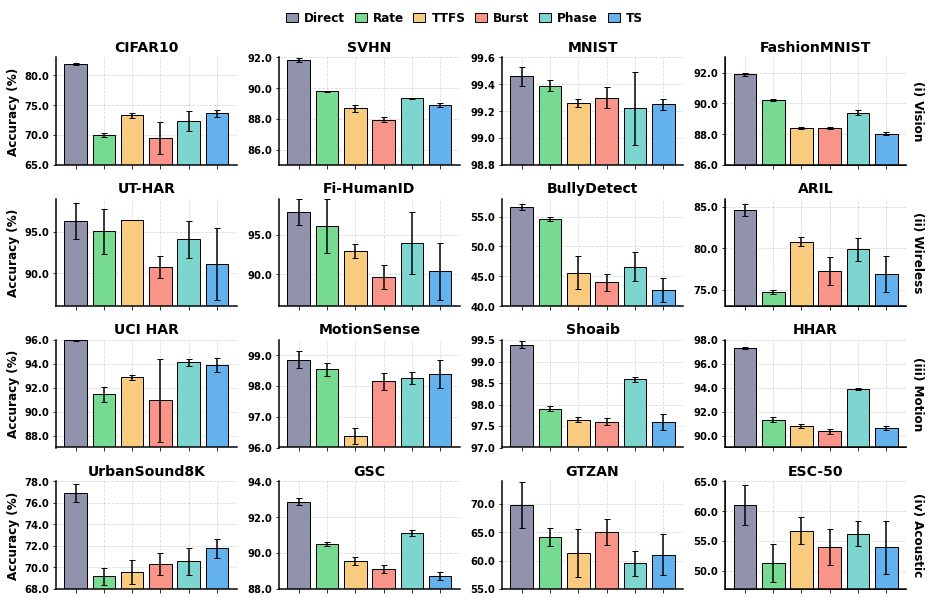

In [3]:
fig, axs = plt.subplots(4, 4, figsize=(13, 8))
categories = ['Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TS']
x = np.arange(len(categories))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic']
for i in range(4):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
        
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        # axs[i].set_yticks([])
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # 设置x label，只有最后一层显示
        axs[i][j].set_xticks(x)
        axs[i][j].set_xticklabels([])

axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)

axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)

axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)

axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)

colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']

# cifar10:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [81.83, 69.95, 73.33, 69.53, 72.35, 73.67]
errors = [0.17, 0.32, 0.40, 2.63, 1.66, 0.59]
axs[0][0].set_ylim(65, 83)
for i in x:
    axs[0][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i], label=categories[i],
        edgecolor='black', zorder=2)
    
# svhn:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [91.83, 89.78, 88.70, 87.95, 89.34, 88.89]
errors = [0.13, 0.04, 0.23, 0.17, 0.02, 0.11]
axs[0][1].set_ylim(85, 92)
for i in x:
    axs[0][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# mnist:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [99.46, 99.39, 99.26, 99.30, 99.22, 99.25]
errors = [0.07, 0.04, 0.03, 0.08, 0.27, 0.04]
axs[0][2].set_ylim(98.8, 99.6)
for i in x:
    axs[0][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# fashionmnist:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [91.90, 90.21, 88.42, 88.42, 89.40, 88.04]
errors = [0.11, 0.08, 0.08, 0.08, 0.18, 0.07]
axs[0][3].set_ylim(86, 93)
for i in x:
    axs[0][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# ut har:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [96.30, 95.06, 96.39, 90.73, 94.07, 91.12]
errors = [2.17, 2.72, 0., 1.38, 2.27, 4.36]
axs[1][0].set_ylim(86, 99)
for i in x:
    axs[1][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# fi-humanid:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [97.82, 96.07, 92.92, 89.67, 93.92, 90.40]
errors = [1.61, 3.42, 0.92, 1.53, 3.93, 3.57]
axs[1][1].set_ylim(86, 99.5)
for i in x:
    axs[1][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# bullydetect:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [56.65, 54.64, 45.64, 44.03, 46.59, 42.63]
errors = [0.47, 0.32, 2.79, 1.43, 2.41, 2.01]
axs[1][2].set_ylim(40, 58)
for i in x:
    axs[1][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# aril:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [84.65, 74.70, 80.82, 77.22, 79.86, 76.86]
errors = [0.75, 0.21, 0.55, 1.70, 1.44, 2.20]
axs[1][3].set_ylim(73, 86)
for i in x:
    axs[1][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# uci har:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'   
values = [96.02, 91.47, 92.87, 90.95, 94.15, 93.92]
errors = [0.09, 0.63, 0.18, 3.45, 0.3, 0.58]
axs[2][0].set_ylim(87, 96)
for i in x:
    axs[2][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# motionsense:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [98.86, 98.54, 96.38, 98.16, 98.26, 98.39]
errors = [0.28, 0.22, 0.27, 0.28, 0.19, 0.45]
axs[2][1].set_ylim(96., 99.5)
for i in x:
    axs[2][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# shoaib:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [99.39, 97.90, 97.65, 97.60, 98.59, 97.59]
errors = [0.08, 0.06, 0.05, 0.08, 0.06, 0.18]
axs[2][2].set_ylim(97, 99.5)
for i in x:
    axs[2][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# hhar:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [97.32, 91.33, 90.82, 90.34, 93.87, 90.61]
errors = [0.07, 0.20, 0.16, 0.18, 0.09, 0.17]
axs[2][3].set_ylim(89, 98)
for i in x:
    axs[2][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)


# urbansound8k:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [76.95, 69.15, 69.59, 70.28, 70.54, 71.77]
errors = [0.84, 0.8, 1.13, 1.04, 1.27, 0.87]
axs[3][0].set_ylim(68, 78)
for i in x:
    axs[3][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# GSC:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [92.85, 90.51, 89.57, 89.10, 91.10, 88.72]
errors = [0.20, 0.11, 0.22, 0.22, 0.17, 0.21]
axs[3][1].set_ylim(88, 94)
for i in x:
    axs[3][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# GTZAN:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [69.83, 64.17, 61.33, 65, 59.50, 61]
errors = [4.01, 1.61, 4.31, 2.29, 2.18, 3.61]
axs[3][2].set_ylim(55, 74)
for i in x:
    axs[3][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# ESC:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [61, 51.33, 56.75, 54, 56.25, 53.92]
errors = [3.36, 3.22, 2.29, 3.04, 2.14, 4.50]
axs[3][3].set_ylim(47, 65)
for i in x:
    axs[3][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

fig.legend(
    categories, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=len(categories), 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=.8, 
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)
fig.tight_layout()
plt.savefig('./cmp-encoding-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

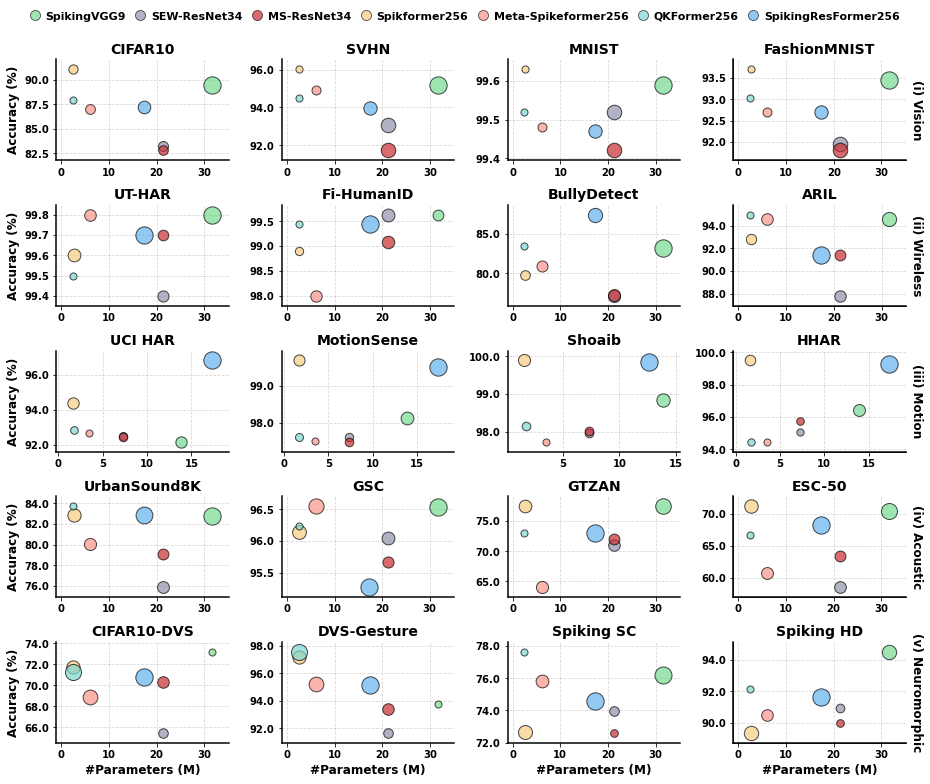

In [4]:
fig, axs = plt.subplots(5, 4, figsize=(13, 10.5))
colors = ['#76da91', '#9192ab', '#c82d31', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
for i in range(5):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        if i == 4:
            axs[i][j].set_xlabel('#Parameters (M)', fontweight='bold', fontsize=12)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
    
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))


def adjust_ylim(ax, y, x=None, pad_ratio=0.12):
    y = np.array(y)
    y_min, y_max = y.min(), y.max()
    y_range = y_max - y_min
    ax.set_ylim(
        y_min - pad_ratio * y_range,
        y_max + pad_ratio * y_range
    )

    if x is not None:
        x = np.array(x)
        x_min, x_max = x.min(), x.max()
        x_range = x_max - x_min
        ax.set_xlim(
            x_min - pad_ratio * x_range,
            x_max + pad_ratio * x_range
        )

s_min, s_max = 50, 300

categories = ['SpikingVGG9', 'SEW-ResNet34','MS-ResNet34', 'Spikformer256', 
              'Meta-Spikeformer256', 'QKFormer256', 'SpikingResFormer256'] # vgg9, resnet34, former2
# cifar10
axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
accs = [89.53, 83.29, 82.79, 91.11, 87.07, 87.93, 87.22]
params = [31.61, 21.29, 21.29, 2.57, 6.09, 2.42, 17.32]
costs = np.array([820.67, 198.23, 176, 153.31, 185.61, 42.31, 384.46])
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][0], accs, params)

# svhn
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
accs = [95.2, 93.08, 91.73, 96.02, 94.93, 94.51, 93.97]
params = np.array([31.61, 21.29, 21.29, 2.57, 6.09, 2.42, 17.32])
costs = np.array([1661.38, 202.65, 177.08, 169.56, 182.88, 45.19, 383.36]) 
sizes = s_min + (params - params.min()) / (params.max() - params.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][1], accs, params)

# mnist
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
accs = [99.59, 99.52, 99.42, 99.63, 99.48, 99.52, 99.47]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([1273.11, 77.77, 69.04, 92.03, 89.69, 23.08, 264.03]) 
sizes = s_min + (params - params.min()) / (params.max() - params.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][2], accs, params)

# fashionmnist
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)
accs = [93.46, 91.95, 91.8, 93.71, 92.71, 93.04, 92.71]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([1192.67, 34.02, 30.25, 114.22, 94.22, 25.81, 199.25]) 
sizes = s_min + (params - params.min()) / (params.max() - params.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][3], accs, params)

# ut-har
axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
accs = [99.8, 99.4, 99.7, 99.6, 99.8, 99.5, 99.7]
params = [31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31]
costs = np.array([4790.23, 1717.97, 1513.71, 2396.2, 1899.94, 426.07, 4748.38]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][0], accs, params)

# fi-humanid
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
accs = [99.63, 99.63, 99.08, 98.9, 97.99, 99.45, 99.45]
params = [31.62, 21.29, 21.3, 2.57, 6.09, 2.42, 17.32]
costs = np.array([7392.13, 11482.72, 10700.59, 3282.74, 8416.59, 1675.69, 22965.19]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][1], accs, params)

# bullydetect
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
accs = [83.26, 77.1, 77.19, 79.82, 80.89, 83.44, 87.46]
params = [31.61, 21.29, 21.29, 2.57, 6.08, 2.41, 17.32]
costs = np.array([6881.04, 3045.48, 2873.80, 1645.20, 2366.06, 533.35, 4427.03]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][2], accs, params)

# aril
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)
accs = [94.60, 87.77, 91.37, 92.81, 94.60, 94.96, 91.37]
params = [31.60, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31]
costs = np.array([1474.34, 868.95, 749.84, 672.84, 901.83, 180.52, 2307.88]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][3], accs, params)

# uci-har
axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
accs = [92.16, 92.47, 92.43, 94.37, 92.64, 92.81, 96.81]
params = [13.87, 7.28, 7.28, 1.63, 3.51, 1.74, 17.31]
costs = np.array([29.79, 10.59, 12.67, 30.31, 5.51, 8.18, 83.15]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][0], accs, params)

# motionsense
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
accs = [98.12, 97.6, 97.48, 99.7, 97.51, 97.6, 99.52]
params = [13.87, 7.28, 7.28, 1.64, 3.51, 1.74, 17.31]
costs = np.array([50.23, 15.11, 16.4, 35.43, 7.72, 13.08, 101.6]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][1], accs, params)

# shoaib
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
accs = [98.84, 97.95, 98.02, 99.89, 97.73, 98.16, 99.86]
params = [13.87, 7.28, 7.28, 1.62, 3.51, 1.74, 12.56]
costs = np.array([51.65, 15.77, 16.55, 40.49, 7.39, 15.73, 93.65]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][2], accs, params)

# hhar
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)
accs = [96.4, 95.05, 95.75, 99.49, 94.47, 94.48, 99.26]
params = [13.87, 7.28, 7.28, 1.62, 3.51, 1.74, 17.31]
costs = np.array([39.55, 3.41, 5.8, 27.32, 2.36, 3.96, 102.73]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][3], accs, params)

# urbansound8k
axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
accs = [82.76, 75.86, 79.07, 82.88, 80.04, 83.73, 82.88]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([3425.88, 1458.24, 1185.28, 1885.05, 1544.79, 328.97, 3219.93]) / 1000 # mj
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][0], accs, params)

# gsc
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
accs = [96.53, 96.04, 95.67, 96.14, 96.55, 96.23, 95.27]
params = np.array([31.66, 21.3, 21.3, 2.57, 6.09, 2.41, 17.32])
costs = np.array([2824.65, 1573.78, 1189.65, 1808.95, 2195.36, 511, 2789.32]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][1], accs, params)

# gtzan
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
accs = [77.5, 71, 72, 77.5, 64, 73, 73]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([2908.94, 1431.12, 1214.06, 1784.31, 1632.79, 311.82, 3672.51]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][2], accs, params)

# esc-50
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)
accs = [70.5, 58.5, 63.5, 71.25, 60.75, 66.75, 68.25]
params = [31.69, 21.3, 21.31, 2.58, 6.09, 2.43, 17.33]
costs = np.array([2931.87, 1433.94, 1196.17, 1981.97, 1485.05, 324.71, 3471.66]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][3], accs, params)


# cifar10-dvs
axs[4][0].set_title('CIFAR10-DVS', fontweight='bold', fontsize=14)
accs = [73.2, 65.45, 70.35, 71.7, 68.85, 71.3, 70.8]
params = [31.61, 21.29, 21.29, 2.57, 6.08, 2.42, 17.32]
costs = np.array([1, 2, 3, 4, 5, 6, 7]) # TODO 后面再改成param是size，x轴是costs
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][0], accs, params)

# dvs-gesture
axs[4][1].set_title('DVS-Gesture', fontweight='bold', fontsize=14)
accs = [93.75, 91.67, 93.4, 97.22, 95.24, 97.57, 95.14]
params = [31.61, 21.29, 21.29, 2.57, 6.08, 2.42, 17.32]
costs = np.array([1, 2, 3, 4, 5, 6, 7]) # TODO 后面再改成param是size，x轴是costs
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][1], accs, params)

# ssc
axs[4][2].set_title('Spiking SC', fontweight='bold', fontsize=14)
accs = [76.22, 73.96, 72.6, 72.69, 75.83, 77.64, 74.61]
params = [31.66, 21.3, 21.3, 2.57, 6.09, 2.42, 17.32]
costs = np.array([5160.73, 1419.89, 775.27, 3382.03, 2731.23, 589.53, 5357.59]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][2], accs, params)

# shd   
axs[4][3].set_title('Spiking HD', fontweight='bold', fontsize=14)
accs = [94.52, 90.95, 89.97, 89.36, 90.5, 92.14, 91.65]
params = [31.63, 21.29, 21.29, 2.57, 6.09, 2.42, 17.32]
costs = np.array([4796.67, 1314.91, 847.97, 4804.35, 2903.08, 603.97, 7333.23]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][3], accs, params)


legend_size = 70
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=colors[i],
        markeredgecolor='black',
        markeredgewidth=0.8,
        alpha=0.7,
        markersize=np.sqrt(legend_size),  # 注意：markersize 是“半径”
        label=categories[i]
    )
    for i in range(len(categories))
]
fig.legend(
    handles=legend_handles,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.04), 
    ncol=7, 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=.8, 
    markerscale=1.2,
    prop={'weight': 'bold', 'size': 11},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-topology-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

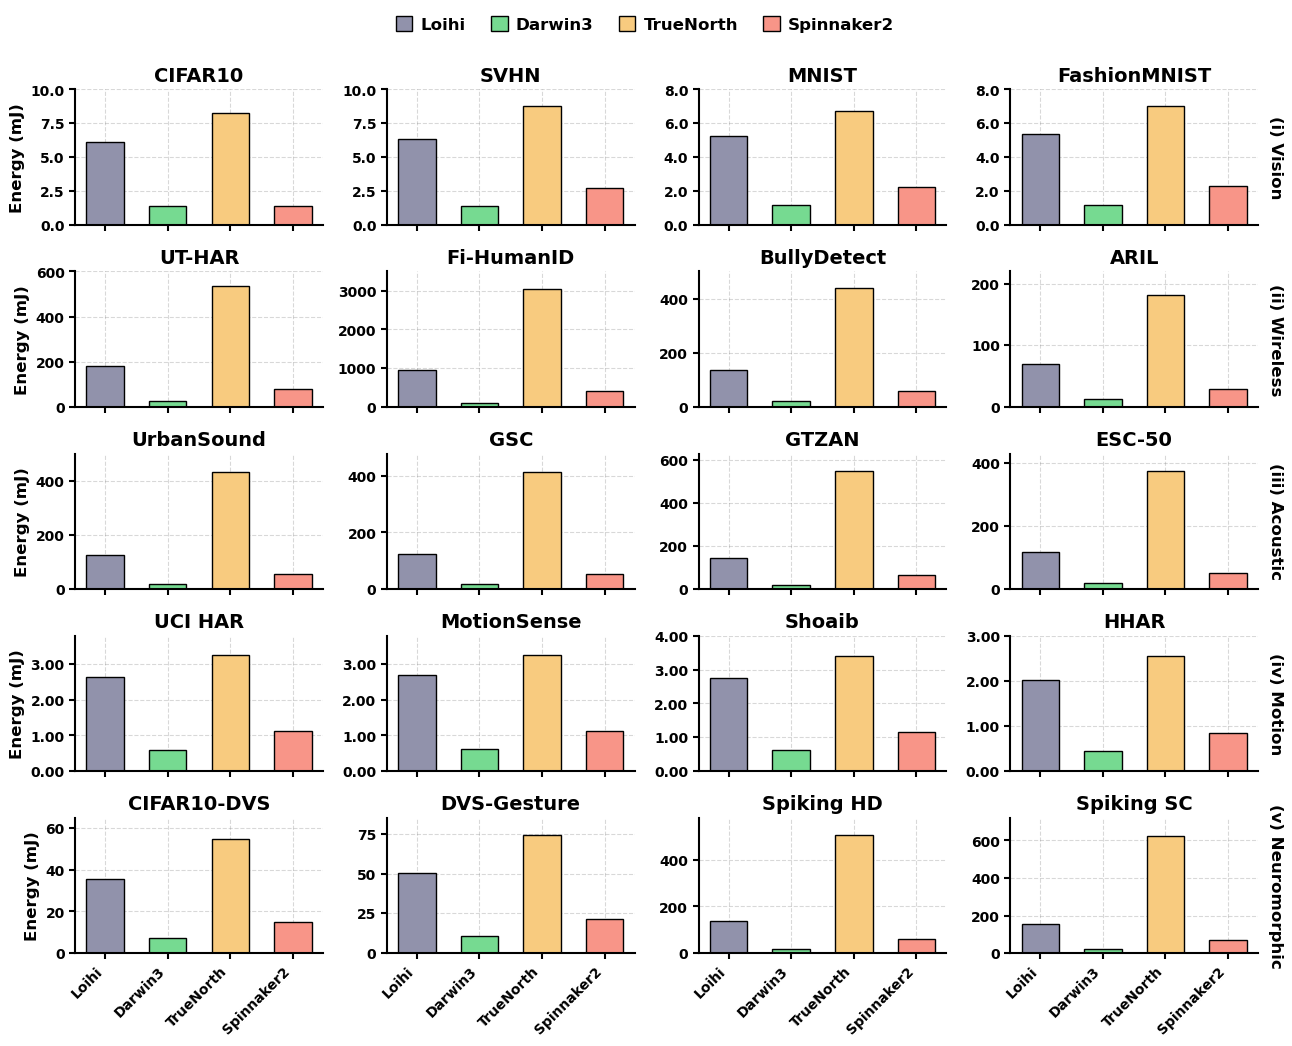

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter

fig, axs = plt.subplots(5, 4, figsize=(13, 10))

devices = ['Loihi', 'Darwin3', 'TrueNorth', 'Spinnaker2']
x = np.arange(len(devices))
colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588']
modalities = ['(i) Vision', '(ii) Wireless', '(iii) Acoustic', '(iv) Motion', '(v) Neuromorphic']

BAR_WIDTH = 0.6 

for row in range(5):
    for col in range(4):
        ax = axs[row][col]
        
        if col == 0:
            ax.set_ylabel('Energy (mJ)', fontweight='bold', fontsize=12, color='black')

        if col == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[row]}', fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.tick_params(axis='x', which='both', bottom=True, top=False, 
                       colors='black', width=1.5, length=4, direction='out')
        ax.tick_params(axis='y', which='both', left=True, right=False, 
                       colors='black', width=1.5, length=4, direction='out')
        
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')
            label.set_color('black')

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('black')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        
        if row == 3: 
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        elif row in [1, 2, 4]: 
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
        else:
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        ax.set_xticks(x)
        if row == 4: 
            ax.set_xticklabels(devices, fontsize=10, fontweight='bold', color='black', 
                               rotation=45, ha='right')
        else:
            ax.set_xticklabels([])

titles = [
    ['CIFAR10', 'SVHN', 'MNIST', 'FashionMNIST'],               
    ['UT-HAR', 'Fi-HumanID', 'BullyDetect', 'ARIL'],            
    ['UrbanSound', 'GSC', 'GTZAN', 'ESC-50'],                   
    ['UCI HAR', 'MotionSense', 'Shoaib', 'HHAR'],               
    ['CIFAR10-DVS', 'DVS-Gesture', 'Spiking HD', 'Spiking SC']  
]

for r in range(5):
    for c in range(4):
        axs[r][c].set_title(titles[r][c], fontweight='bold', fontsize=14, color='black')

def plot_bar(ax, values):
    for k in x:
        ax.bar(
            k, values[k],
            width=BAR_WIDTH, 
            color=colors[k],
            edgecolor='black', 
            linewidth=1.0, 
            zorder=2
        )

# Vision
values = [6.1437, 1.3738, 8.27, 1.3738]
axs[0][0].set_ylim(0, 10)
plot_bar(axs[0][0], values)

values = [6.3147, 1.4067, 8.7677, 2.6758]
axs[0][1].set_ylim(0, 10)
plot_bar(axs[0][1], values)

values = [5.2618, 1.1638, 6.7371, 2.2296]
axs[0][2].set_ylim(0, 8)
plot_bar(axs[0][2], values)

values = [5.3863, 1.1868, 7.0405, 2.2823]
axs[0][3].set_ylim(0, 8)
plot_bar(axs[0][3], values)

# Wireless
values = [180.0229, 26.8994, 533.5221, 76.852]
axs[1][0].set_ylim(0, 600)
plot_bar(axs[1][0], values)

values = [940.8663, 92.0029, 3040.3329, 413.5679]
axs[1][1].set_ylim(0, 3500)
plot_bar(axs[1][1], values)

values = [135.6374, 21.0083, 437.5203, 58.2449]
axs[1][2].set_ylim(0, 500)
plot_bar(axs[1][2], values)

values = [70.0194, 12.0706, 182.4128, 29.5083]
axs[1][3].set_ylim(0, 220)
plot_bar(axs[1][3], values)

# Acoustic
values = [125.8839, 19.0423, 430.2877, 54.3214]
axs[2][0].set_ylim(0, 500)
plot_bar(axs[2][0], values)

values = [123.8498, 18.9577, 413.3128, 53.2872]
axs[2][1].set_ylim(0, 480)
plot_bar(axs[2][1], values)

values = [145.1369, 20.1845, 547.0841, 62.6666]
axs[2][2].set_ylim(0, 630)
plot_bar(axs[2][2], values)

values = [117.5003, 18.5628, 374.8386, 50.8244]
axs[2][3].set_ylim(0, 430)
plot_bar(axs[2][3], values)

# Motion
values = [2.6331, 0.5953, 3.2527, 1.1157]
axs[3][0].set_ylim(0, 3.8)
plot_bar(axs[3][0], values)

values = [2.6834, 0.6087, 3.2598, 1.137]
axs[3][1].set_ylim(0, 3.8)
plot_bar(axs[3][1], values)

values = [2.7417, 0.6205, 3.3851, 1.1617]
axs[3][2].set_ylim(0, 4.0)
plot_bar(axs[3][2], values)

values = [2.0133, 0.4533, 2.5457, 0.8514]
axs[3][3].set_ylim(0, 3.0)
plot_bar(axs[3][3], values)

# Neuromorphic
values = [35.3693, 7.469, 54.9007, 14.7843]
axs[4][0].set_ylim(0, 65)
plot_bar(axs[4][0], values)

values = [50.6123, 10.7699, 73.9036, 21.3573]
axs[4][1].set_ylim(0, 85)
plot_bar(axs[4][1], values)

values = [137.1459, 19.4016, 504.7549, 59.3721]
axs[4][2].set_ylim(0, 580)
plot_bar(axs[4][2], values)

values = [156.6937, 20.5925, 621.0846, 67.5835]
axs[4][3].set_ylim(0, 720)
plot_bar(axs[4][3], values)

legend_patches = []
for c, l in zip(colors, devices):
    patch = mpatches.Patch(
        facecolor=c, 
        edgecolor='black', 
        linewidth=1.0, 
        label=l
    )
    legend_patches.append(patch)

fig.legend(
    handles=legend_patches,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=len(devices), 
    handlelength=1,     
    handleheight=1,     
    handletextpad=0.5, 
    columnspacing=1.5, 
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-energy-sensing-processors.pdf', dpi=300, bbox_inches="tight")
plt.show()

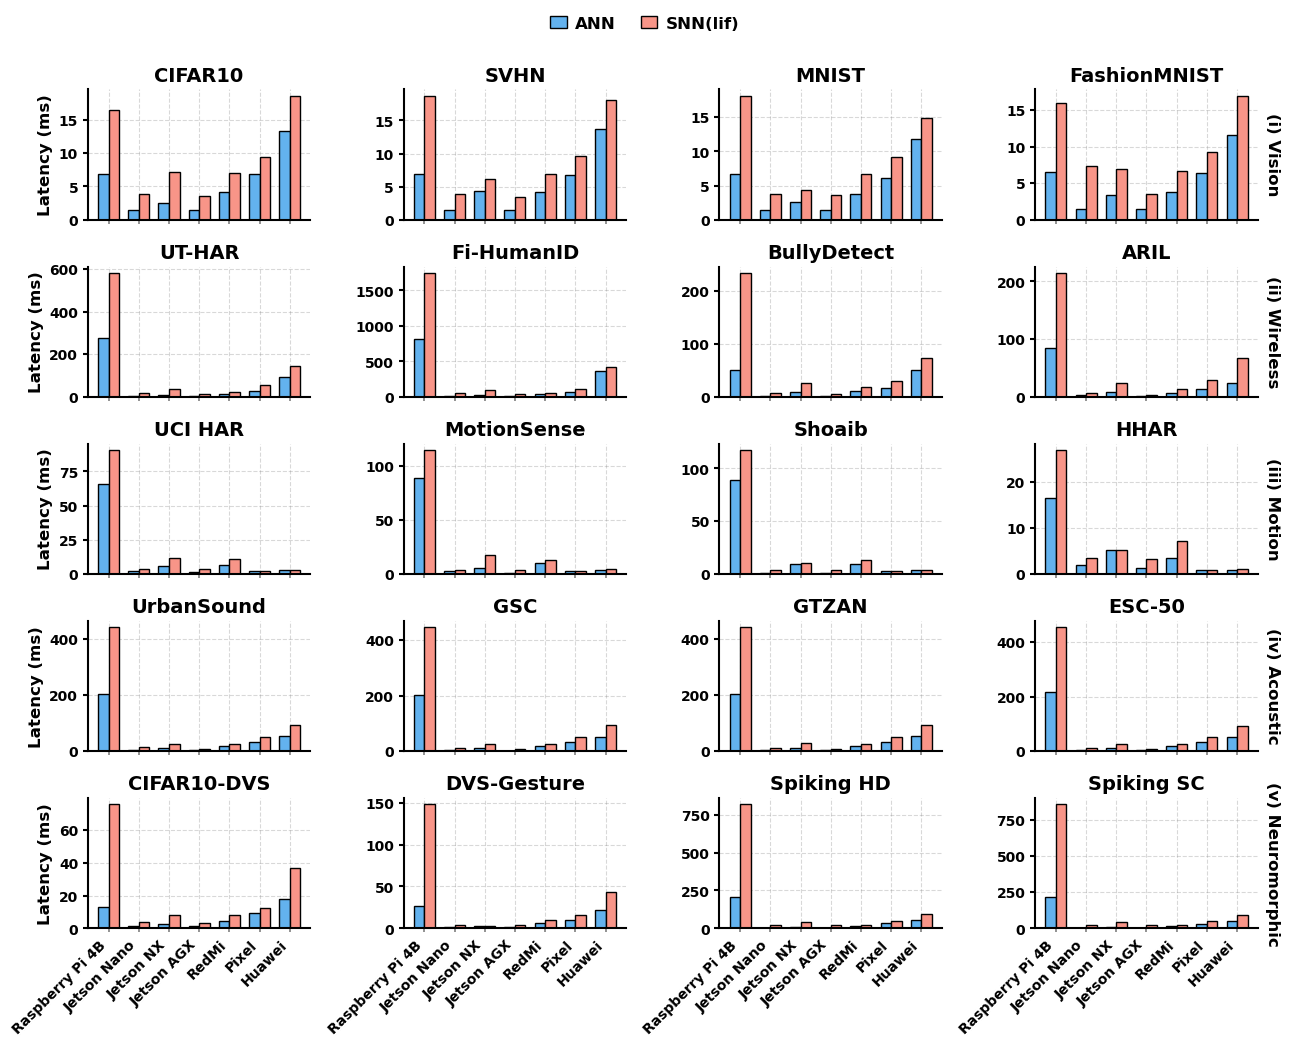

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

devices = ['Raspberry Pi 4B', 'Jetson Nano', 'Jetson NX', 'Jetson AGX', 'RedMi', 'Pixel', 'Huawei']
x = np.arange(len(devices))

data = {
    "Vision": {
        "CIFAR10": {"ann": [6.809, 1.441, 2.456, 1.384, 4.137, 6.895, 13.373], "snn": [16.516, 3.929, 7.138, 3.563, 6.968, 9.430, 18.686]},
        "SVHN": {"ann": [6.837, 1.446, 4.321, 1.396, 4.130, 6.736, 13.691], "snn": [18.774, 3.939, 6.11, 3.475, 6.950, 9.601, 18.146]},
        "MNIST": {"ann": [6.672, 1.48, 2.596, 1.392, 3.768, 6.148, 11.801], "snn": [18.193, 3.707, 4.325, 3.616, 6.748, 9.147, 14.856]},
        "FashionMNIST": {"ann": [6.547, 1.409, 3.372, 1.409, 3.763, 6.370, 11.545], "snn": [15.945, 7.39, 6.9, 3.558, 6.723, 9.327, 16.998]}
    },
    "Wireless": {
        "UT-HAR": {"ann": [276.546, 3.043, 10.933, 2.468, 11.996, 27.807, 91.280], "snn": [582.708, 17.698, 37.74, 12.217, 22.312, 56.381, 144.796]},
        "Fi-HumanID": {"ann": [820.848, 10.497, 21.544, 6.805, 45.500, 75.207, 360.103], "snn": [1749.858, 52.495, 99.821, 39.899, 58.812, 104.643, 427.715]},
        "BullyDetect": {"ann": [50.137, 2.488, 9.392, 1.446, 11.809, 17.158, 50.747], "snn": [234.911, 7.13, 25.909, 6.241, 19.456, 29.501, 74.157]},
        "ARIL": {"ann": [85.174, 2.637, 9.124, 1.739, 6.688, 14.172, 24.510], "snn": [215.049, 6.14, 24.814, 4.038, 13.726, 28.733, 66.945]}
    },
    "Motion": {
        "UCI HAR": {"ann": [65.982, 2.211, 5.798, 1.377, 6.826, 2.382, 2.670], "snn": [90.65, 3.829, 11.876, 3.385, 10.721, 2.421, 3.225]},
        "MotionSense": {"ann": [88.777, 2.735, 5.895, 1.384, 9.980, 3.021, 3.435], "snn": [114.469, 3.691, 17.523, 3.569, 12.998, 3.218, 4.447]},
        "Shoaib": {"ann": [88.951, 1.45, 9.544, 1.356, 9.964, 3.061, 3.528], "snn": [117.567, 3.762, 10.033, 3.413, 13.058, 3.169, 4.273]},
        "HHAR": {"ann": [16.512, 1.951, 5.268, 1.36, 3.408, 0.791, 0.803], "snn": [26.884, 3.561, 5.299, 3.35, 7.098, 0.823, 1.097]}
    },
    "Acoustic": {
        "UrbanSound": {"ann": [202.943, 2.742, 10.041, 2.851, 18.458, 33.467, 53.355], "snn": [441.249, 16.652, 25.793, 8.906, 27.213, 50.266, 92.101]},
        "GSC": {"ann": [200.71, 5.299, 9.965, 1.898, 18.396, 33.631, 52.913], "snn": [446.305, 10.712, 26.672, 8.91, 27.102, 50.267, 93.409]},
        "GTZAN": {"ann": [202.025, 5.535, 11.834, 3.064, 18.470, 33.485, 52.911], "snn": [440.765, 10.726, 28.996, 8.916, 27.362, 50.451, 92.044]},
        "ESC-50": {"ann": [217.735, 5.495, 10.505, 2.854, 18.241, 33.598, 53.618], "snn": [453.891, 10.74, 25.943, 8.94, 26.945, 50.317, 92.857]}
    },
    "Neuromorphic": {
        "CIFAR10-DVS": {"ann": [12.821, 1.408, 2.481, 1.424, 4.757, 9.176, 18.085], "snn": [75.823, 3.809, 8.447, 3.53, 8.321, 12.316, 36.738]},
        "DVS-Gesture": {"ann": [26.973, 1.755, 2.315, 1.422, 5.900, 10.289, 21.903], "snn": [147.987, 4.318, 2.315, 3.83, 9.552, 16.219, 42.918]},
        "Spiking HD": {"ann": [210.121, 5.274, 9.901, 4.289, 18.456, 33.527, 53.443], "snn": [817.99, 20.542, 44.702, 20.507, 24.369, 50.509, 92.923]},
        "Spiking SC": {"ann": [218.134, 4.782, 9.964, 4.284, 18.476, 33.357, 53.331], "snn": [855.917, 20.549, 44.768, 20.514, 24.310, 50.999, 93.645]}
    }
}

modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']

modality_labels = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']
c_ann = colors[5]  
c_snn = colors[3]  

fig, axs = plt.subplots(5, 4, figsize=(13, 10)) 
width = 0.35

for i, modality in enumerate(modalities):
    datasets = list(data[modality].keys())
    
    for j in range(4):
        ax = axs[i][j]
        
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('black')
        
        ax.spines['bottom'].set_visible(True)
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('black')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        
        for label in ax.get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')
            label.set_color('black')

        if j == 0:
            ax.set_ylabel('Latency (ms)', fontweight='bold', fontsize=12, color='black')

        if j == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modality_labels[i]}', fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f')) 
        ax.tick_params(axis='y', colors='black', width=1.5)

        ax.set_xticks(x)

        ax.tick_params(
            axis='x', 
            colors='gray',    
            width=1.2,        
            length=3,         
            direction='out',
            top=False, 
            bottom=True
        )

        if i == 4: 
            ax.set_xticklabels(devices, fontsize=10, fontweight='bold', color='black', 
                               rotation=45, ha='right')
        else:
            ax.set_xticklabels([])

        if j < len(datasets):
            d_name = datasets[j]
            ax.set_title(d_name, fontweight='bold', fontsize=14, color='black')
            
            ann_vals = data[modality][d_name]['ann']
            snn_vals = data[modality][d_name]['snn']
            
            ax.bar(x - width/2, ann_vals, width, label='ANN', color=c_ann, edgecolor='black', zorder=2)
            ax.bar(x + width/2, snn_vals, width, label='SNN(lif)', color=c_snn, edgecolor='black', zorder=2)
        else:
            ax.axis('off')

fig.legend(
    ['ANN', 'SNN(lif)'], 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=2, 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=1.5,
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-latency-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

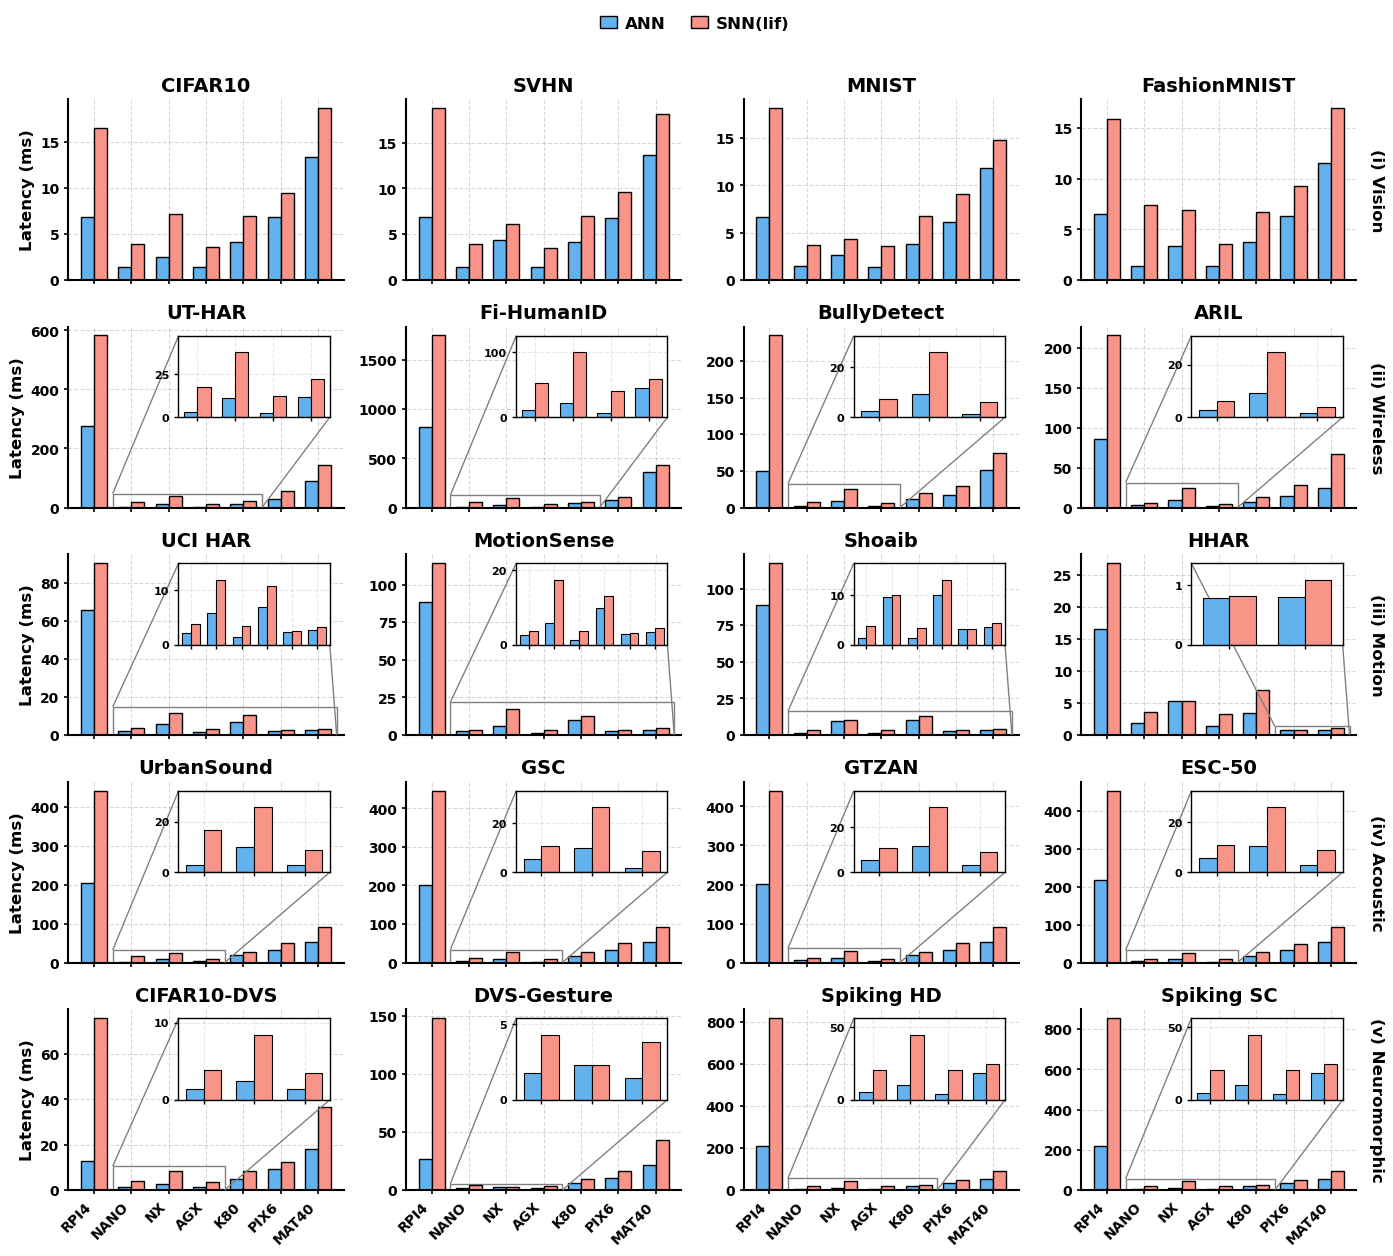

In [96]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

devices_short = ['RPI4', 'NANO', 'NX', 'AGX', 'K80', 'PIX6', 'MAT40']
x = np.arange(len(devices_short))

# 颜色定义
colors = ['#9192ab', '#f8cb7f', '#76da91', '#7cd6cf', '#63b2ee', '#cca4e3', '#f89588']

# ANN 和 SNN 的颜色
ann_color = '#63b2ee'  # 天蓝
snn_color = '#f89588'  # 浅粉

data = {
    "Vision": {
        "CIFAR10": {"ann": [6.809, 1.441, 2.456, 1.384, 4.137, 6.895, 13.373], "snn": [16.516, 3.929, 7.138, 3.563, 6.968, 9.430, 18.686]},
        "SVHN": {"ann": [6.837, 1.446, 4.321, 1.396, 4.130, 6.736, 13.691], "snn": [18.774, 3.939, 6.11, 3.475, 6.950, 9.601, 18.146]},
        "MNIST": {"ann": [6.672, 1.48, 2.596, 1.392, 3.768, 6.148, 11.801], "snn": [18.193, 3.707, 4.325, 3.616, 6.748, 9.147, 14.856]},
        "FashionMNIST": {"ann": [6.547, 1.409, 3.372, 1.409, 3.763, 6.370, 11.545], "snn": [15.945, 7.39, 6.9, 3.558, 6.723, 9.327, 16.998]}
    },
    "Wireless": {
        "UT-HAR": {"ann": [276.546, 3.043, 10.933, 2.468, 11.996, 27.807, 91.280], "snn": [582.708, 17.698, 37.74, 12.217, 22.312, 56.381, 144.796]},
        "Fi-HumanID": {"ann": [820.848, 10.497, 21.544, 6.805, 45.500, 75.207, 360.103], "snn": [1749.858, 52.495, 99.821, 39.899, 58.812, 104.643, 427.715]},
        "BullyDetect": {"ann": [50.137, 2.488, 9.392, 1.446, 11.809, 17.158, 50.747], "snn": [234.911, 7.13, 25.909, 6.241, 19.456, 29.501, 74.157]},
        "ARIL": {"ann": [85.174, 2.637, 9.124, 1.739, 6.688, 14.172, 24.510], "snn": [215.049, 6.14, 24.814, 4.038, 13.726, 28.733, 66.945]}
    },
    "Motion": {
        "UCI HAR": {"ann": [65.982, 2.211, 5.798, 1.377, 6.826, 2.382, 2.670], "snn": [90.65, 3.829, 11.876, 3.385, 10.721, 2.421, 3.225]},
        "MotionSense": {"ann": [88.777, 2.735, 5.895, 1.384, 9.980, 3.021, 3.435], "snn": [114.469, 3.691, 17.523, 3.569, 12.998, 3.218, 4.447]},
        "Shoaib": {"ann": [88.951, 1.45, 9.544, 1.356, 9.964, 3.061, 3.528], "snn": [117.567, 3.762, 10.033, 3.413, 13.058, 3.169, 4.273]},
        "HHAR": {"ann": [16.512, 1.951, 5.268, 1.36, 3.408, 0.791, 0.803], "snn": [26.884, 3.561, 5.299, 3.35, 7.098, 0.823, 1.097]}
    },
    "Acoustic": {
        "UrbanSound": {"ann": [202.943, 2.742, 10.041, 2.851, 18.458, 33.467, 53.355], "snn": [441.249, 16.652, 25.793, 8.906, 27.213, 50.266, 92.101]},
        "GSC": {"ann": [200.71, 5.299, 9.965, 1.898, 18.396, 33.631, 52.913], "snn": [446.305, 10.712, 26.672, 8.91, 27.102, 50.267, 93.409]},
        "GTZAN": {"ann": [202.025, 5.535, 11.834, 3.064, 18.470, 33.485, 52.911], "snn": [440.765, 10.726, 28.996, 8.916, 27.362, 50.451, 92.044]},
        "ESC-50": {"ann": [217.735, 5.495, 10.505, 2.854, 18.241, 33.598, 53.618], "snn": [453.891, 10.74, 25.943, 8.94, 26.945, 50.317, 92.857]}
    },
    "Neuromorphic": {
        "CIFAR10-DVS": {"ann": [12.821, 1.408, 2.481, 1.424, 4.757, 9.176, 18.085], "snn": [75.823, 3.809, 8.447, 3.53, 8.321, 12.316, 36.738]},
        "DVS-Gesture": {"ann": [26.973, 1.755, 2.315, 1.422, 5.900, 10.289, 21.903], "snn": [147.987, 4.318, 2.315, 3.83, 9.552, 16.219, 42.918]},
        "Spiking HD": {"ann": [210.121, 5.274, 9.901, 4.289, 18.456, 33.527, 53.443], "snn": [817.99, 20.542, 44.702, 20.507, 24.369, 50.509, 92.923]},
        "Spiking SC": {"ann": [218.134, 4.782, 9.964, 4.284, 18.476, 33.357, 53.331], "snn": [855.917, 20.549, 44.768, 20.514, 24.310, 50.999, 93.645]}
    }
}

modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']
modality_labels = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

inset_config = {
    (0,0): None, (0,1): None, (0,2): None, (0,3): None,
    (1,0): [1, 2, 3, 4], (1,1): [1, 2, 3, 4], (1,2): [1, 2, 3], (1,3): [1, 2, 3],
    (2,0): [1, 2, 3, 4, 5, 6], (2,1): [1, 2, 3, 4, 5, 6], (2,2): [1, 2, 3, 4, 5, 6], (2,3): [5, 6],
    (3,0): [1, 2, 3], (3,1): [1, 2, 3], (3,2): [1, 2, 3], (3,3): [1, 2, 3],
    (4,0): [1, 2, 3], (4,1): [1, 2, 3], (4,2): [1, 2, 3, 4], (4,3): [1, 2, 3, 4]
}

fig, axs = plt.subplots(5, 4, figsize=(14, 12))
width = 0.35

for i, modality in enumerate(modalities):
    datasets = list(data[modality].keys())

    for j in range(4):
        ax = axs[i][j]

        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_visible(True)
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('black')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)

        for label in ax.get_yticklabels():
            label.set_fontsize(10)
            label.set_fontweight('bold')
            label.set_color('black')

        if j == 0:
            ax.set_ylabel('Latency (ms)', fontweight='bold', fontsize=12, color='black')

        if j == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(modality_labels[i], fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
        ax.tick_params(
            axis='y', colors='black', width=1.2, length=3, direction='out',
            left=True, right=False
        )

        ax.set_xticks(x)
        ax.tick_params(
            axis='x', colors='black', width=1.2, length=3, direction='out',
            top=False, bottom=True
        )

        if i == 4:
            ax.set_xticklabels(devices_short, fontsize=10, fontweight='bold', color='black',
                               rotation=45, ha='right')
        else:
            ax.set_xticklabels([])

        if j < len(datasets):
            d_name = datasets[j]
            ax.set_title(d_name, fontweight='bold', fontsize=14, color='black')

            ann_vals = data[modality][d_name]['ann']
            snn_vals = data[modality][d_name]['snn']

            # 使用指定的颜色
            ax.bar(x - width/2, ann_vals, width, label='ANN', color=ann_color, edgecolor='black', zorder=2)
            ax.bar(x + width/2, snn_vals, width, label='SNN(lif)', color=snn_color, edgecolor='black', zorder=2)

            indices_to_show = inset_config.get((i, j))
            if indices_to_show:
                zoom_indices = np.array(indices_to_show)
                zoom_ann = np.array(ann_vals)[zoom_indices]
                zoom_snn = np.array(snn_vals)[zoom_indices]
                zoom_x = x[zoom_indices]

                zoom_max = max(zoom_ann.max(), zoom_snn.max())

                # 使用 ax.inset_axes 创建内嵌子图
                axins = ax.inset_axes([0.40, 0.50, 0.55, 0.45])

                # 使用指定的颜色
                axins.bar(zoom_x - width/2, zoom_ann, width, color=ann_color, edgecolor='black', linewidth=0.8, zorder=2)
                axins.bar(zoom_x + width/2, zoom_snn, width, color=snn_color, edgecolor='black', linewidth=0.8, zorder=2)

                axins.set_xlim(zoom_indices.min() - 0.5, zoom_indices.max() + 0.5)
                axins.set_ylim(0, zoom_max * 1.25)

                # 内嵌子图刻度设置
                axins.set_xticks(zoom_x)
                axins.tick_params(
                    axis='x', which='major',
                    bottom=True, top=False,
                    labelbottom=False,
                    colors='black',
                    width=1.0, length=3, direction='out'
                )
                axins.tick_params(
                    axis='y', which='major',
                    left=True, right=False,
                    labelleft=True,
                    colors='black',
                    width=1.0, length=3, direction='out'
                )

                # Y轴标签样式
                for label in axins.get_yticklabels():
                    label.set_fontsize(8)
                    label.set_fontweight('bold')
                    label.set_color('black')

                # Y轴格式化
                axins.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

                axins.set_facecolor('white')
                axins.grid(True, linestyle='--', alpha=0.3, zorder=0)

                for spine in axins.spines.values():
                    spine.set_edgecolor('black')
                    spine.set_linewidth(1.0)

                mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="grey", lw=1.0, linestyle='-')
        else:
            ax.axis('off')

fig.legend(
    ['ANN', 'SNN(lif)'],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2,
    handlelength=1,
    handletextpad=0.5,
    columnspacing=1.5,
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-latency-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

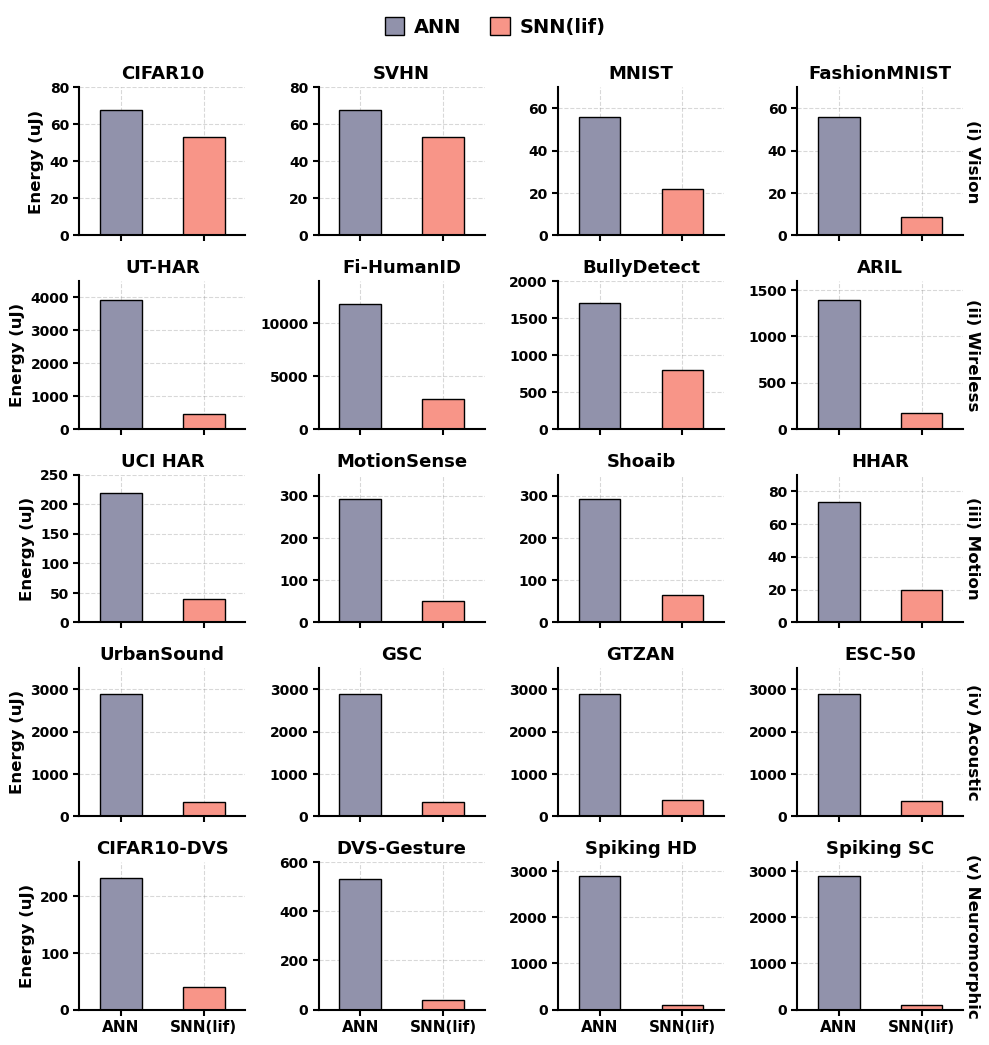

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter

fig, axs = plt.subplots(5, 4, figsize=(10, 10))

categories = ['ANN', 'SNN(lif)']
x = np.arange(len(categories))

colors = ['#9192ab', '#f89588'] 

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

BAR_WIDTH = 0.5 

for row in range(5):
    for col in range(4):
        ax = axs[row][col]
        
        if col == 0:
            ax.set_ylabel('Energy (uJ)', fontweight='bold', fontsize=12, color='black')

        if col == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[row]}', fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.tick_params(axis='x', which='both', bottom=True, top=False, 
                       colors='black', width=1.5, length=4, direction='out')
        ax.tick_params(axis='y', which='both', left=True, right=False, 
                       colors='black', width=1.5, length=4, direction='out')
        
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')
            label.set_color('black')

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('black')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

        ax.set_xticks([0, 1]) 
        ax.set_xlim(-0.5, 1.5) 

        if row == 4: 
            ax.set_xticklabels(categories, fontsize=11, fontweight='bold', color='black', 
                               rotation=0)
        else:
            ax.set_xticklabels([])

titles = [
    ['CIFAR10', 'SVHN', 'MNIST', 'FashionMNIST'],               
    ['UT-HAR', 'Fi-HumanID', 'BullyDetect', 'ARIL'],            
    ['UCI HAR', 'MotionSense', 'Shoaib', 'HHAR'],               
    ['UrbanSound', 'GSC', 'GTZAN', 'ESC-50'],                   
    ['CIFAR10-DVS', 'DVS-Gesture', 'Spiking HD', 'Spiking SC']  
]

for r in range(5):
    for c in range(4):
        axs[r][c].set_title(titles[r][c], fontweight='bold', fontsize=13, color='black')

def plot_pair(ax, ann_val, snn_val):
    ax.bar(0, ann_val, width=BAR_WIDTH, color=colors[0], edgecolor='black', linewidth=1.0, zorder=2)
    ax.bar(1, snn_val, width=BAR_WIDTH, color=colors[1], edgecolor='black', linewidth=1.0, zorder=2)

# Row 0: Vision
# CIFAR10
axs[0][0].set_ylim(0, 80)
plot_pair(axs[0][0], 67.49, 52.9)
# SVHN
axs[0][1].set_ylim(0, 80)
plot_pair(axs[0][1], 67.49, 52.94)
# MNIST
axs[0][2].set_ylim(0, 70)
plot_pair(axs[0][2], 55.95, 21.93)
# FashionMNIST
axs[0][3].set_ylim(0, 70)
plot_pair(axs[0][3], 55.95, 8.74)

# Row 1: Wireless
# UT-HAR
axs[1][0].set_ylim(0, 4500)
plot_pair(axs[1][0], 3919.48, 452)
# Fi-HumanID
axs[1][1].set_ylim(0, 14000)
plot_pair(axs[1][1], 11790.94, 2853.14)
# BullyDetect
axs[1][2].set_ylim(0, 2000)
plot_pair(axs[1][2], 1698.64, 791.23)
# ARIL
axs[1][3].set_ylim(0, 1600)
plot_pair(axs[1][3], 1388.92, 174.85)

# Row 2: Motio===
# UCI HAR
axs[2][0].set_ylim(0, 250)
plot_pair(axs[2][0], 219.52, 39.48)
# MotionSense
axs[2][1].set_ylim(0, 350)
plot_pair(axs[2][1], 292.69, 49.76)
# Shoaib
axs[2][2].set_ylim(0, 350)
plot_pair(axs[2][2], 292.69, 64.14)
# HHAR
axs[2][3].set_ylim(0, 90)
plot_pair(axs[2][3], 73.19, 19.98)

# Row 3: Acoustic===
# UrbanSound
axs[3][0].set_ylim(0, 3500)
plot_pair(axs[3][0], 2891.85, 322.84)
# GSC
axs[3][1].set_ylim(0, 3500)
plot_pair(axs[3][1], 2891.97, 321.21)
# GTZAN
axs[3][2].set_ylim(0, 3500)
plot_pair(axs[3][2], 2891.85, 383.19)
# ESC-50
axs[3][3].set_ylim(0, 3500)
plot_pair(axs[3][3], 2892.04, 363.67)

# Row 4: Neuromorphic
# CIFAR10-DVS
axs[4][0].set_ylim(0, 260)
plot_pair(axs[4][0], 230.93, 40.14)
# DVS-Gesture
axs[4][1].set_ylim(0, 600)
plot_pair(axs[4][1], 528.68, 40.39)
# Spiking HD
axs[4][2].set_ylim(0, 3200)
plot_pair(axs[4][2], 2891.9, 97.76)
# Spiking SC
axs[4][3].set_ylim(0, 3200)
plot_pair(axs[4][3], 2891.97, 104.04)

legend_patches = [
    mpatches.Patch(facecolor=colors[0], edgecolor='black', linewidth=1.0, label='ANN'),
    mpatches.Patch(facecolor=colors[1], edgecolor='black', linewidth=1.0, label='SNN(lif)')
]

fig.legend(
    handles=legend_patches,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=2, 
    handlelength=1,     
    handleheight=1,     
    handletextpad=0.5, 
    columnspacing=1.5, 
    prop={'weight': 'bold', 'size': 14},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-energy-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

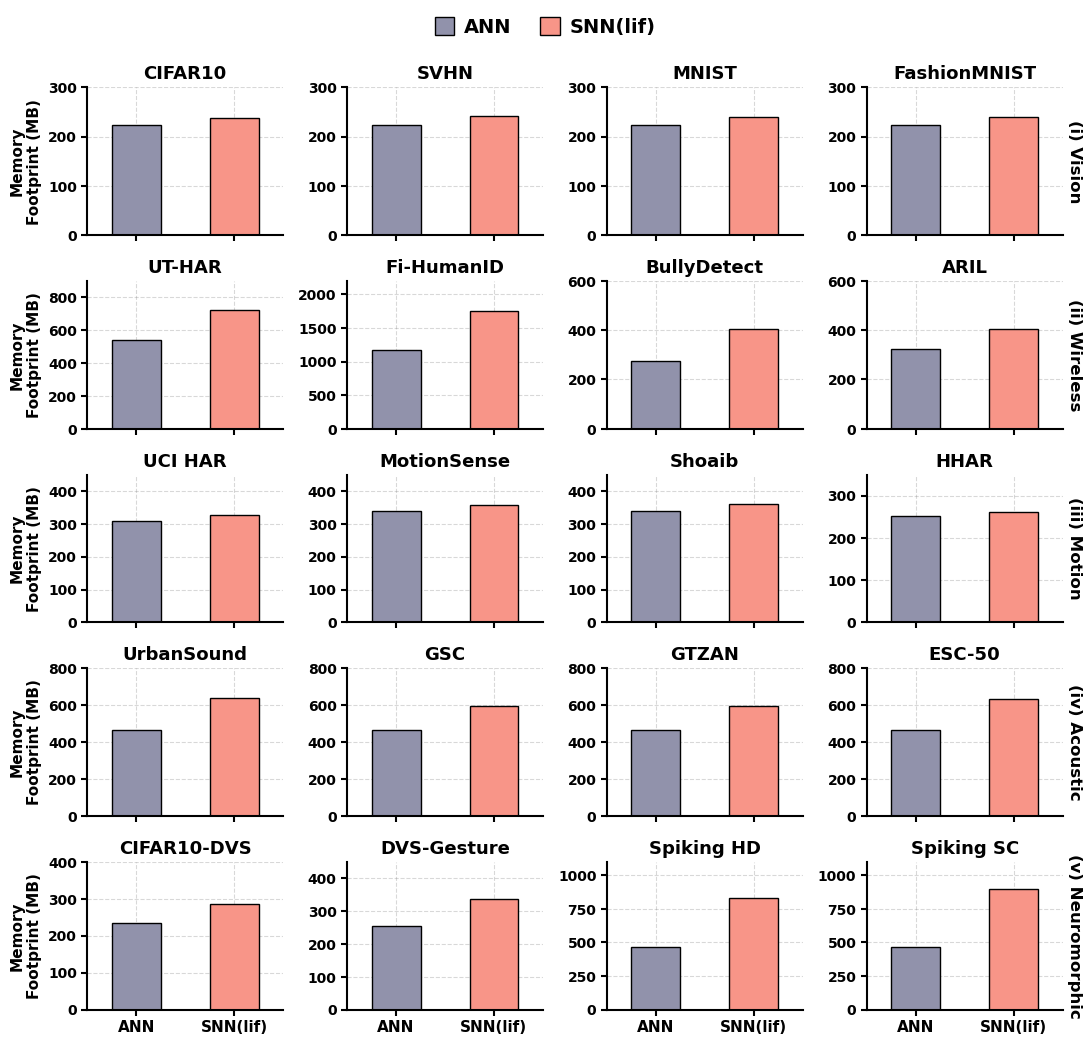

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter

fig, axs = plt.subplots(5, 4, figsize=(11, 10))

categories = ['ANN', 'SNN(lif)']
x = np.arange(len(categories))

colors = ['#9192ab', '#f89588'] 

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

BAR_WIDTH = 0.5  

for row in range(5):
    for col in range(4):
        ax = axs[row][col]

        if col == 0:
            ax.set_ylabel('Memory\nFootprint (MB)', fontweight='bold', fontsize=11, color='black')

        if col == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[row]}', fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.tick_params(axis='x', which='both', bottom=True, top=False, 
                       colors='black', width=1.5, length=4, direction='out')
        ax.tick_params(axis='y', which='both', left=True, right=False, 
                       colors='black', width=1.5, length=4, direction='out')
        
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')
            label.set_color('black')

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('black')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

        ax.set_xticks([0, 1]) 
        ax.set_xlim(-0.5, 1.5)  

        if row == 4: 
            ax.set_xticklabels(categories, fontsize=11, fontweight='bold', color='black', 
                               rotation=0)
        else:
            ax.set_xticklabels([])

titles = [
    ['CIFAR10', 'SVHN', 'MNIST', 'FashionMNIST'],               
    ['UT-HAR', 'Fi-HumanID', 'BullyDetect', 'ARIL'],            
    ['UCI HAR', 'MotionSense', 'Shoaib', 'HHAR'],              
    ['UrbanSound', 'GSC', 'GTZAN', 'ESC-50'],                  
    ['CIFAR10-DVS', 'DVS-Gesture', 'Spiking HD', 'Spiking SC']  
]

for r in range(5):
    for c in range(4):
        axs[r][c].set_title(titles[r][c], fontweight='bold', fontsize=13, color='black')

def plot_pair(ax, ann_val, snn_val):
    ax.bar(0, ann_val, width=BAR_WIDTH, color=colors[0], edgecolor='black', linewidth=1.0, zorder=2)
    ax.bar(1, snn_val, width=BAR_WIDTH, color=colors[1], edgecolor='black', linewidth=1.0, zorder=2)


# Row 0: Vision
axs[0][0].set_ylim(0, 300)
plot_pair(axs[0][0], 223.86, 237.94)
axs[0][1].set_ylim(0, 300)
plot_pair(axs[0][1], 224.38, 241.11)
axs[0][2].set_ylim(0, 300)
plot_pair(axs[0][2], 224.24, 239)
axs[0][3].set_ylim(0, 300)
plot_pair(axs[0][3], 224.16, 239.57)

# Row 1: Wireless
axs[1][0].set_ylim(0, 900)
plot_pair(axs[1][0], 542.88, 720.6)
axs[1][1].set_ylim(0, 2200)
plot_pair(axs[1][1], 1174.66, 1759.98)
axs[1][2].set_ylim(0, 600)
plot_pair(axs[1][2], 276.08, 405.82)
axs[1][3].set_ylim(0, 600)
plot_pair(axs[1][3], 324.39, 403.08)

# Row 2: Motion===
axs[2][0].set_ylim(0, 450)
plot_pair(axs[2][0], 309.73, 326.43)
axs[2][1].set_ylim(0, 450)
plot_pair(axs[2][1], 337.81, 356.82)
axs[2][2].set_ylim(0, 450)
plot_pair(axs[2][2], 338.12, 361.31)
axs[2][3].set_ylim(0, 350)
plot_pair(axs[2][3], 252.11, 261.78)

# Row 3: Acoustic ===
axs[3][0].set_ylim(0, 800)
plot_pair(axs[3][0], 464.24, 640.93)
axs[3][1].set_ylim(0, 800)
plot_pair(axs[3][1], 466.2, 594.13)
axs[3][2].set_ylim(0, 800)
plot_pair(axs[3][2], 465.18, 593.33)
axs[3][3].set_ylim(0, 800)
plot_pair(axs[3][3], 465.93, 635.27)

# Row 4: Neuromorphic
axs[4][0].set_ylim(0, 400)
plot_pair(axs[4][0], 234.7, 286.11)
axs[4][1].set_ylim(0, 450)
plot_pair(axs[4][1], 255.98, 337.35)
axs[4][2].set_ylim(0, 1100)
plot_pair(axs[4][2], 465.95, 833.8)
axs[4][3].set_ylim(0, 1100)
plot_pair(axs[4][3], 466.04, 898.14)

legend_patches = [
    mpatches.Patch(facecolor=colors[0], edgecolor='black', linewidth=1.0, label='ANN'),
    mpatches.Patch(facecolor=colors[1], edgecolor='black', linewidth=1.0, label='SNN(lif)')
]

fig.legend(
    handles=legend_patches,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=2, 
    handlelength=1,     
    handleheight=1,     
    handletextpad=0.5, 
    columnspacing=1.5, 
    prop={'weight': 'bold', 'size': 14},
    frameon=False,
)

fig.subplots_adjust(wspace=0.3)
fig.tight_layout()
plt.savefig('./cmp-footprint-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

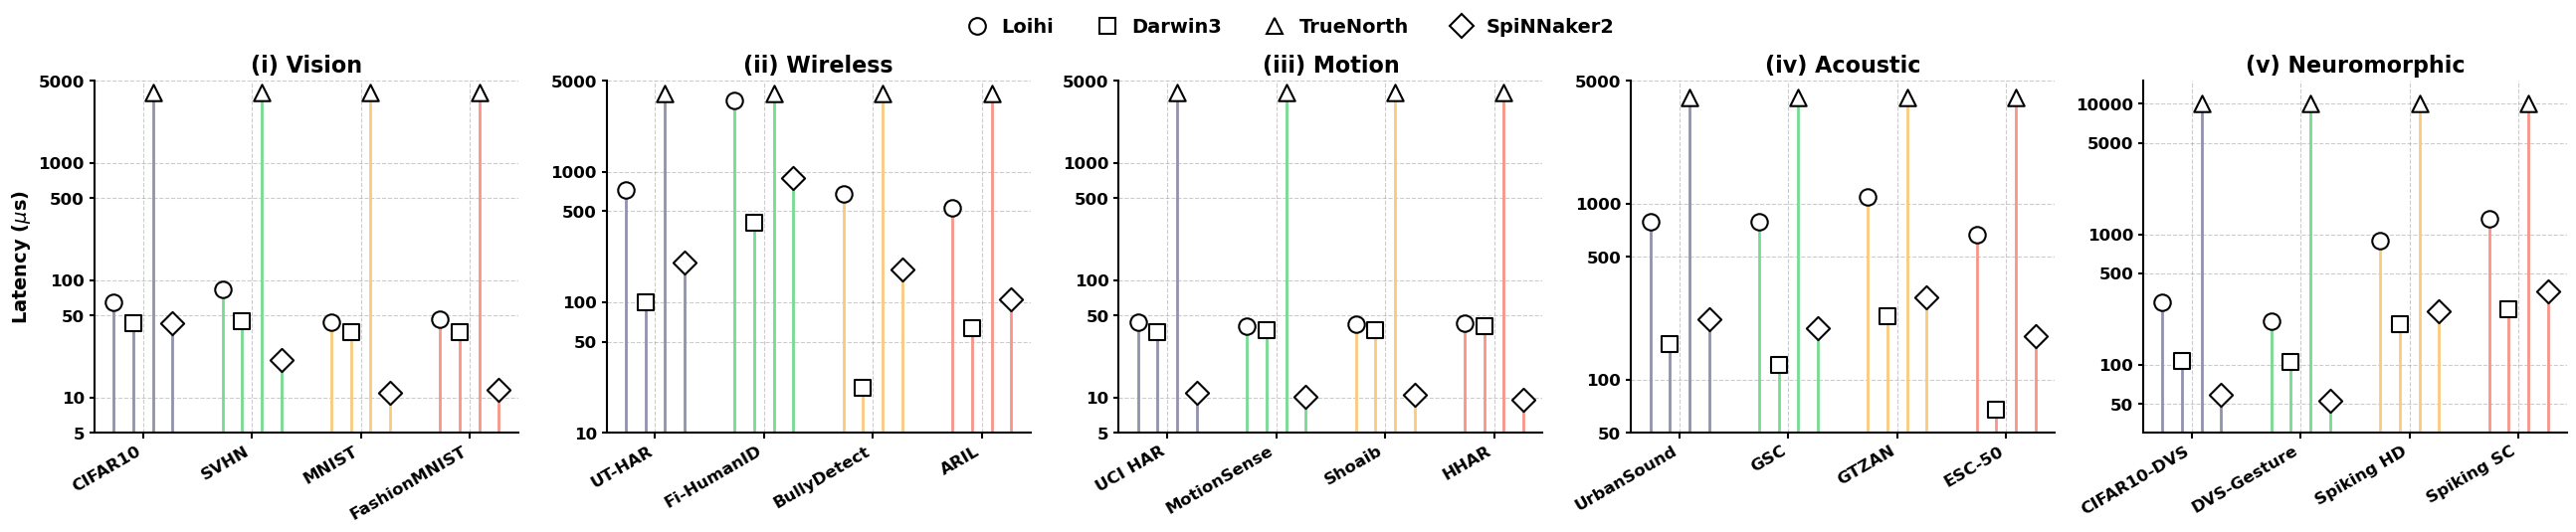

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

chips = ['Loihi', 'Darwin3', 'TrueNorth', 'SpiNNaker2']

data = {
    "Vision": {
        "CIFAR10": [64.54, 43.31, 4000, 43.31],
        "SVHN": [83.91, 44.98, 4000, 20.98],
        "MNIST": [43.97, 36.34, 4000, 10.99],
        "FashionMNIST": [46.19, 36.33, 4000, 11.55]
    },
    "Wireless": {
        "UT-HAR": [731.6, 100.08, 4000, 202.27],
        "Fi-HumanID": [3540.63, 405.63, 4000, 906.60],
        "BullyDetect": [675.09, 22.12, 4000, 180.13],
        "ARIL": [528.5, 64.11, 4000, 106.10]
    },
    "Motion": {
        "UCI HAR": [43.51, 36.37, 4000, 10.88],
        "MotionSense": [40.91, 37.87, 4000, 10.23],
        "Shoaib": [42.33, 37.87, 4000, 10.58],
        "HHAR": [42.82, 40.52, 4000, 9.61]
    },
    "Acoustic": {
        "UrbanSound": [796.31, 160.53, 4000, 220.88],
        "GSC": [792.58, 121.39, 4000, 197.98],
        "GTZAN": [1093.01, 229.76, 4000, 295.01],
        "ESC-50": [665.71, 68.08, 4000, 178.21]
    },
    "Neuromorphic": {
        "CIFAR10-DVS": [301.4, 107.08, 10000, 59.00],
        "DVS-Gesture": [216.37, 105.82, 10000, 52.57],
        "Spiking HD": [887.84, 203.19, 10000, 255.55],
        "Spiking SC": [1322.38, 268.45, 10000, 368.05]
    }
}

marker_color = 'white'

line_colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588']

chip_markers = ['o', 's', '^', 'D']

modalities = list(data.keys())

modality_titles = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

y_axis_config = {
    "Vision": {
        "ylim": (5, 5000),
        "yticks": [5, 10, 50, 100, 500, 1000, 5000]
    },
    "Wireless": {
        "ylim": (10, 5000),
        "yticks": [10, 50, 100, 500, 1000, 5000]
    },
    "Motion": {
        "ylim": (5, 5000),
        "yticks": [5, 10, 50, 100, 500, 1000, 5000]
    },
    "Acoustic": {
        "ylim": (50, 5000),
        "yticks": [50, 100, 500, 1000, 5000]
    },
    "Neuromorphic": {
        "ylim": (30, 15000),
        "yticks": [50, 100, 500, 1000, 5000, 10000]
    }
}

fig, axs = plt.subplots(1, 5, figsize=(26, 5))

bar_width = 0.18

for col_idx, modality in enumerate(modalities):
    ax = axs[col_idx]
    datasets = list(data[modality].keys())
    x = np.arange(len(datasets))
    
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.4, zorder=0)
    
    ax.set_title(modality_titles[col_idx], fontweight='bold', fontsize=16, color='black')
    
    config = y_axis_config[modality]
    ymin = config["ylim"][0]
    
    for dataset_idx, dataset in enumerate(datasets):
        values = data[modality][dataset]
        
        for chip_idx, chip in enumerate(chips):
            val = values[chip_idx]
            
            offset = (chip_idx - 1.5) * bar_width
            xpos = dataset_idx + offset
            
            ax.vlines(xpos, ymin=ymin, ymax=val,
                      color=line_colors[dataset_idx],
                      linewidth=2,
                      zorder=2)
            
            ax.scatter(xpos, val,
                       s=140,
                       color=marker_color,
                       edgecolor='black',
                       linewidth=1.5,
                       marker=chip_markers[chip_idx],
                       zorder=3)
    
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=12, fontweight='bold', color='black', 
                      rotation=30, ha='right')
    ax.tick_params(axis='x', colors='black', width=1.5, length=4, direction='out', 
                  top=False, bottom=True)
    
    ax.set_yscale('log')
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')
    
    ax.minorticks_off()
    ax.tick_params(axis='y', which='major', colors='black', width=1.5)
    
    for label in ax.get_yticklabels():
        label.set_fontsize(12)       
        label.set_fontweight('bold')
        label.set_color('black')
    
    if col_idx == 0:
        ax.set_ylabel(r'Latency ($\mu$s)', fontweight='bold', fontsize=14, color='black')

chip_legend_elements = [Line2D([0], [0], color='black', marker=chip_markers[i], 
                                markersize=12, markerfacecolor='white',
                                markeredgecolor='black', markeredgewidth=1.5,
                                linewidth=0, label=chip)
                        for i, chip in enumerate(chips)]

fig.legend(
    handles=chip_legend_elements,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.08), 
    ncol=4, 
    handlelength=1.5,  
    handletextpad=0.5, 
    columnspacing=2,
    prop={'weight': 'bold', 'size': 14},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-latency-sensing-processors.pdf', dpi=300, bbox_inches='tight')
plt.show()

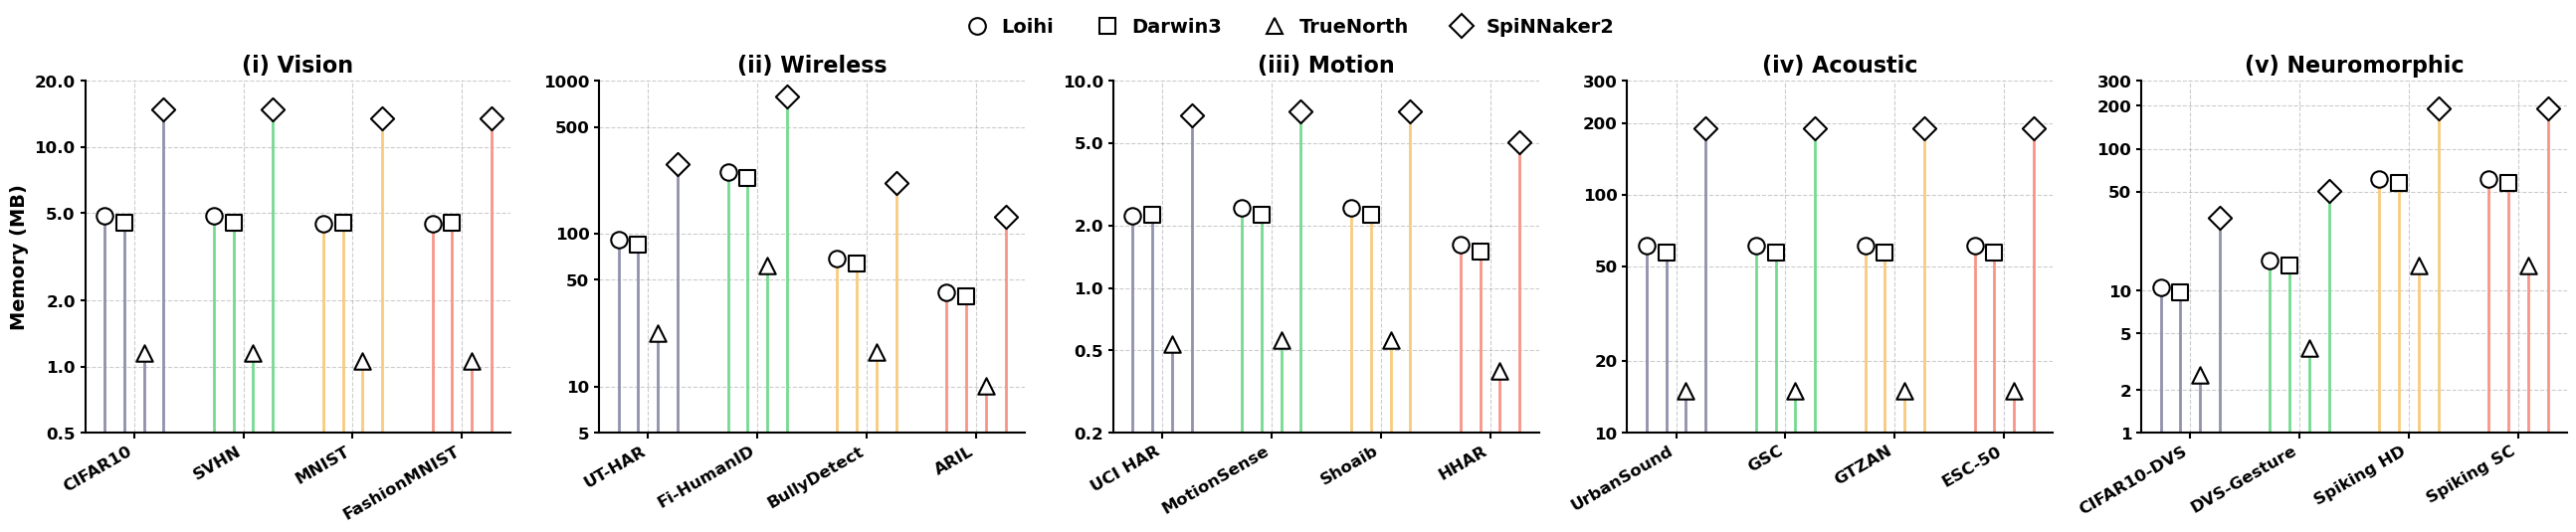

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

chips = ['Loihi', 'Darwin3', 'TrueNorth', 'SpiNNaker2']

data = {
    "Vision": {
        "CIFAR10": [4992, 4608, 1185.75, 15118.31],
        "SVHN": [4992, 4608, 1185.75, 15118.31],
        "MNIST": [4576, 4608, 1083.75, 13817.81],
        "FashionMNIST": [4576, 4608, 1083.75, 13817.81]
    },
    "Wireless": {
        "UT-HAR": [93392, 86784, 22886.25, 291799.69],
        "Fi-HumanID": [258752, 238848, 63444, 808911],
        "BullyDetect": [70720, 65280, 17340, 221085],
        "ARIL": [42640, 39936, 10455, 133301.25]
    },
    "Motion": {
        "UCI HAR": [2288, 2304, 548.25, 6990.19],
        "MotionSense": [2496, 2304, 573.75, 7315.31],
        "Shoaib": [2496, 2304, 573.75, 7315.31],
        "HHAR": [1664, 1536, 408, 5202]
    },
    "Acoustic": {
        "UrbanSound": [62608, 58368, 15312.75, 195237.56],
        "GSC": [62608, 58368, 15312.75, 195237.56],
        "GTZAN": [62608, 58368, 15312.75, 195237.56],
        "ESC-50": [62608, 58368, 15312.75, 195237.56]
    },
    "Neuromorphic": {
        "CIFAR10-DVS": [10816, 9984, 2613.75, 33325.31],
        "DVS-Gesture": [16640, 15360, 4041.75, 51532.31],
        "Spiking HD": [62608, 58368, 15312.75, 195237.56],
        "Spiking SC": [62608, 58368, 15312.75, 195237.56]
    }
}

marker_color = 'white'

line_colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588']

chip_markers = ['o', 's', '^', 'D']

modalities = list(data.keys())

modality_titles = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

y_axis_config = {
    "Vision": {
        "ylim": (0.5, 20),
        "yticks": [0.5, 1, 2, 5, 10, 20]
    },
    "Wireless": {
        "ylim": (5, 1000),
        "yticks": [5, 10, 50, 100, 500, 1000]
    },
    "Motion": {
        "ylim": (0.2, 10),
        "yticks": [0.2, 0.5, 1, 2, 5, 10]
    },
    "Acoustic": {
        "ylim": (10, 300),
        "yticks": [10, 20, 50, 100, 200, 300]
    },
    "Neuromorphic": {
        "ylim": (1, 300),
        "yticks": [1, 2, 5, 10, 50, 100, 200, 300]
    }
}

fig, axs = plt.subplots(1, 5, figsize=(26, 5))

bar_width = 0.18

for col_idx, modality in enumerate(modalities):
    ax = axs[col_idx]
    datasets = list(data[modality].keys())
    x = np.arange(len(datasets))
    
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.4, zorder=0)
    
    ax.set_title(modality_titles[col_idx], fontweight='bold', fontsize=16, color='black')
    
    config = y_axis_config[modality]
    ymin = config["ylim"][0]
    
    for dataset_idx, dataset in enumerate(datasets):
        values = data[modality][dataset]
        
        for chip_idx, chip in enumerate(chips):
            val = values[chip_idx] / 1024 
            
            offset = (chip_idx - 1.5) * bar_width
            xpos = dataset_idx + offset
            
            ax.vlines(xpos, ymin=ymin, ymax=val,
                      color=line_colors[dataset_idx],
                      linewidth=2,
                      zorder=2)
            
            ax.scatter(xpos, val,
                       s=140,
                       color=marker_color,
                       edgecolor='black',
                       linewidth=1.5,
                       marker=chip_markers[chip_idx],
                       zorder=3)
    
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=12, fontweight='bold', color='black', 
                      rotation=30, ha='right')
    ax.tick_params(axis='x', colors='black', width=1.5, length=4, direction='out', 
                  top=False, bottom=True)
    
    ax.set_yscale('log')
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')
    
    ax.minorticks_off()
    ax.tick_params(axis='y', which='major', colors='black', width=1.5)
    
    for label in ax.get_yticklabels():
        label.set_fontsize(12)       
        label.set_fontweight('bold')
        label.set_color('black')
    
    if col_idx == 0:
        ax.set_ylabel('Memory (MB)', fontweight='bold', fontsize=14, color='black')

chip_legend_elements = [Line2D([0], [0], color='black', marker=chip_markers[i], 
                                markersize=12, markerfacecolor='white',
                                markeredgecolor='black', markeredgewidth=1.5,
                                linewidth=0, label=chip)
                        for i, chip in enumerate(chips)]

fig.legend(
    handles=chip_legend_elements,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.08),
    ncol=4, 
    handlelength=1.5,  
    handletextpad=0.5, 
    columnspacing=2,
    prop={'weight': 'bold', 'size': 14},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-memory-sensing-processors.pdf', dpi=300, bbox_inches='tight')
plt.show()

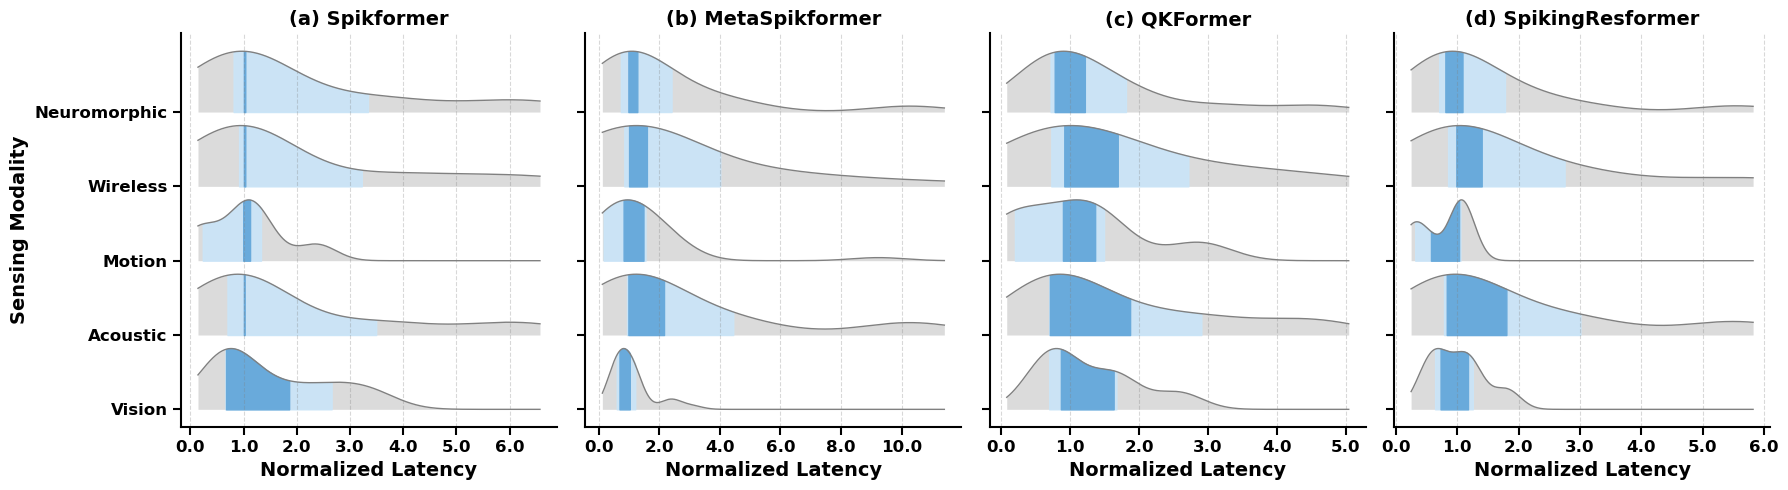

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.ticker import FormatStrFormatter

# 1. 基础设置
modalities = ['Vision', 'Acoustic', 'Motion', 'Wireless', 'Neuromorphic']

# 2. 数据录入 (4个模型)

# --- Spikformer ---
data_former = {
    'Vision': np.array([
        [28.97, 29.17, 27.82, 148.56, 44.11, 83.29, 117.12],
        [29.07, 29.05, 27.65, 149.34, 44.23, 82.27, 117.69],
        [28.74, 28.26, 27.22, 148.38, 43.93, 81.74, 117.69],
        [28.90, 27.87, 27.06, 149.27, 43.94, 81.78, 117.96],
    ]),
    'Acoustic': np.array([
        [336.00, 496.55, 478.47, 3007.20, 334.08, 511.94, 1779.81],
        [336.22, 498.24, 493.58, 3038.83, 333.84, 509.45, 1769.63],
        [338.40, 495.08, 491.12, 3042.14, 332.12, 515.80, 1719.18],
        [342.67, 492.95, 490.13, 3052.42, 332.67, 511.90, 1788.38],
    ]),
    'Motion': np.array([
        [14.93, 20.41, 19.55, 14.31, 34.91, 2.07, 3.29],
        [14.92, 16.71, 19.73, 14.37, 34.97, 2.10, 3.40],
        [14.57, 16.81, 19.73, 14.31, 35.07, 2.15, 3.36],
        [14.41, 17.33, 19.53, 14.01, 34.81, 2.07, 3.27],
    ]),
    'Wireless': np.array([
        [543.95, 679.52, 659.25, 4288.69, 495.37, 794.03, 2692.83],
        [2324.27, 2542.72, 2555.48, 14219.16, 1288.60, 2746.03, 7770.61],
        [331.78, 494.56, 490.51, 2933.97, 322.40, 506.47, 1865.52],
        [188.73, 215.19, 228.52, 1691.12, 206.17, 301.56, 976.24],
    ]),
    'Neuromorphic': np.array([
        [46.99, 52.02, 48.38, 353.78, 63.81, 126.35, 208.79],
        [73.34, 100.59, 102.02, 687.33, 94.89, 195.11, 382.52],
        [339.02, 501.25, 493.17, 3095.10, 336.13, 534.05, 1791.04],
        [337.82, 498.11, 495.30, 3067.64, 334.68, 516.84, 1789.05],
    ]),
}

# --- MetaSpikformer256 ---
data_meta = {
    'Vision': np.array([
        [29.879745, 31.213285, 36.451061, 54.848857, 57.514682, 66.287767, 169.119134],
        [30.353431, 32.254139, 36.717924, 54.855974, 57.349977, 66.827844, 129.079232],
        [30.140677, 30.294922, 36.269082, 54.150467, 57.114785, 66.160190, 133.253721],
        [29.978310, 30.227089, 36.241088, 53.888007, 56.951018, 67.826619, 125.075042]
    ]),
    'Wireless': np.array([
        [84.530567, 107.552947, 113.023065, 1369.463421, 111.583998, 265.491185, 601.451678],
        [169.137552, 227.270227, 224.587024, 4128.135742, 192.054520, 354.483490, 1431.175503],
        [74.850940, 95.727066, 80.306303, 960.471973, 104.190511, 189.398038, 407.242778],
        [58.296193, 39.026232, 62.861556, 597.418900, 79.947577, 174.555395, 347.534433]
    ]),
    'Acoustic': np.array([
        [68.039631, 85.263609, 90.442480, 966.391298, 93.852460, 206.236958, 417.853040],
        [67.902531, 86.204225, 90.586832, 964.227976, 93.910176, 206.538748, 442.706032],
        [68.213387, 84.672653, 90.104057, 964.197523, 93.945114, 204.567535, 418.188388],
        [67.977433, 83.954504, 90.285655, 966.561499, 93.787378, 204.555628, 416.947833]
    ]),
    'Motion': np.array([
        [23.117468, 36.406030, 34.386422, 18.378629, 55.910342, 2.772308, 3.627049],
        [22.960914, 36.051074, 34.957861, 18.381292, 56.572996, 2.760770, 3.621637],
        [22.978819, 35.964411, 34.497065, 18.411944, 56.133215, 2.774240, 3.613399],
        [22.981655, 212.298093, 34.174318, 17.630121, 55.558054, 2.612675, 3.324658]
    ]),
    'Neuromorphic': np.array([
        [33.652916, 33.882614, 38.033356, 117.823906, 60.861167, 76.402524, 194.278007],
        [39.953395, 43.773594, 41.151238, 215.145193, 64.819951, 91.403317, 229.077081],
        [67.966352, 85.863343, 90.208564, 967.165116, 93.978835, 201.398759, 442.210315],
        [67.950288, 85.615591, 90.009391, 964.350210, 94.224207, 202.057384, 444.843651]
    ])
}

# --- QKFormer256 ---
data_qk = {
    'Vision': np.array([
        [14.047385, 25.162462, 21.482872, 17.453946, 42.190729, 42.711184, 65.431610],
        [14.193813, 25.429895, 21.710348, 17.413655, 41.519543, 41.746161, 64.734968],
        [14.206443, 25.346307, 21.266424, 16.821252, 41.605981, 41.852014, 64.673782],
        [13.996754, 24.928929, 21.312929, 17.027401, 41.944358, 41.869121, 64.788078]
    ]),
    'Wireless': np.array([
        [47.278682, 54.121906, 56.677606, 419.877016, 78.625601, 144.759430, 282.376161],
        [93.188534, 130.535261, 117.949391, 1203.611896, 119.001406, 238.674445, 548.538462],
        [42.602516, 57.903926, 56.018703, 311.292671, 71.660783, 119.496464, 202.481287],
        [29.922211, 31.673585, 38.772096, 176.839039, 57.239214, 102.116051, 153.958909]
    ]),
    'Acoustic': np.array([
        [46.178085, 44.841755, 46.279670, 301.313510, 66.220647, 124.353214, 195.324434],
        [37.971911, 46.166285, 46.061033, 300.060395, 65.934642, 125.084923, 210.331795],
        [37.819187, 44.518301, 46.169969, 298.986772, 66.389874, 124.636122, 195.440329],
        [37.875957, 45.776321, 45.959442, 297.420870, 66.444190, 124.256945, 192.356453]
    ]),
    'Motion': np.array([
        [15.270098, 23.309586, 21.653589, 10.435090, 43.585147, 1.542286, 2.267878],
        [15.342453, 23.181004, 21.593380, 13.665133, 43.843807, 2.166124, 3.016353],
        [15.495917, 23.104898, 21.695800, 13.687007, 44.020507, 2.187300, 2.996851],
        [14.671265, 23.158991, 19.876686, 4.695116, 42.969956, 0.702714, 0.920490]
    ]),
    'Neuromorphic': np.array([
        [16.066874, 27.901797, 28.808592, 37.225810, 44.824859, 46.963764, 77.153615],
        [19.249040, 30.896641, 31.368251, 65.646099, 47.818411, 73.791100, 90.368860],
        [46.900800, 48.183183, 46.056216, 303.355133, 66.266836, 121.525325, 210.537131],
        [46.253793, 47.575202, 45.880485, 302.795326, 66.718434, 120.695584, 212.179642]
    ])
}

# --- SpikingResformer256 ---
data_resformer = {
    'Vision': np.array([
        [23.309990, 34.857972, 29.539178, 48.506954, 60.724160, 57.060857, 85.749304],
        [23.267578, 34.710389, 30.173360, 48.478316, 60.694321, 57.004048, 86.894775],
        [23.254549, 33.389206, 29.616000, 47.073001, 60.643286, 56.361492, 85.726113],
        [23.111658, 33.603604, 29.277885, 47.336588, 59.969746, 56.250546, 87.200011]
    ]),
    'Wireless': np.array([
        [104.535910, 136.496936, 130.027784, 953.410215, 159.535760, 277.273175, 521.074581],
        [272.585772, 417.645014, 413.303867, 3140.708543, 362.876266, 552.956224, 1135.456492],
        [82.676801, 110.172734, 108.855772, 667.007127, 119.487160, 211.702675, 344.992257],
        [62.627340, 74.694698, 76.465087, 470.684800, 99.416688, 176.797150, 283.645428]
    ]),
    'Acoustic': np.array([
        [71.662065, 92.226106, 90.070653, 640.802765, 115.552966, 209.650816, 349.924546],
        [71.686790, 90.106884, 89.652661, 643.012593, 115.863699, 208.943840, 349.313357],
        [71.465774, 95.486685, 90.055399, 639.542427, 116.241750, 209.446895, 349.848211],
        [63.399930, 93.006580, 89.796072, 642.430313, 115.661017, 209.148998, 350.298049]
    ]),
    'Motion': np.array([
        [58.528801, 111.121621, 104.031944, 108.550746, 126.091129, 25.545423, 32.064232],
        [58.853970, 109.262028, 104.794826, 108.320057, 126.813712, 25.396611, 31.951455],
        [58.343771, 112.163126, 104.209766, 109.304720, 125.471828, 25.662641, 32.006665],
        [58.610421, 111.170348, 103.946211, 108.031842, 124.929285, 25.575704, 32.132602]
    ]),
    'Neuromorphic': np.array([
        [30.359831, 38.933532, 35.906682, 93.353894, 66.004051, 70.136877, 115.583290],
        [37.030366, 48.516914, 50.268104, 157.560379, 70.905886, 84.920673, 142.814803],
        [71.705251, 91.329080, 89.523082, 644.080212, 115.600560, 207.054668, 349.901278],
        [71.743274, 93.387846, 89.889179, 641.433434, 116.305636, 206.441029, 349.962268]
    ])
}

# 3. 创建子图 (1x4 布局)
fig, axs = plt.subplots(1, 4, figsize=(18, 5))

def draw_kde(ax, data, index, show_ylabel=True):
    # 深拷贝避免修改原数据
    data_copy = {k: v.copy() for k, v in data.items()}
    
    # 归一化
    for mod in modalities:
        lat_norm = data_copy[mod] / np.median(data_copy[mod], axis=1, keepdims=True)
        data_copy[mod] = lat_norm.flatten()

    ridge_data = [data_copy[mod] for mod in modalities]

    offset = 1.1
    x_all = np.concatenate(ridge_data)
    x_min, x_max = np.percentile(x_all, [1, 99])
    x = np.linspace(x_min, x_max, 500)

    for i, values in enumerate(ridge_data):
        kde = gaussian_kde(values)
        y = kde(x)
        y = y / y.max() * 0.9

        base = i * offset

        # 轮廓线
        ax.plot(x, y + base, color='gray', linewidth=1)
        
        # 基础填充
        ax.fill_between(x, base, y + base, 
                        color='lightgray', alpha=0.8, linewidth=0)

        # 分位数区域填充
        q1, q2, q3 = np.percentile(values, [25, 50, 75])
        q_low, q_high = np.percentile(values, [40, 60])

        ax.fill_between(x, base, y + base,
                        where=(x >= q1) & (x <= q3),
                        color='#CAE5F8', alpha=0.9)

        ax.fill_between(x, base, y + base,
                        where=(x >= q_low) & (x <= q_high),
                        color='#69AADB', alpha=1.0)

    # Y轴设置
    ax.set_yticks(np.arange(len(modalities)) * offset)
    
    # 只有第一张图显示Y轴标签
    if show_ylabel:
        ax.set_yticklabels(modalities)
        ax.set_ylabel('Sensing Modality', fontweight='bold', fontsize=14)
    else:
        ax.set_yticklabels([])
    
    # X轴设置
    ax.set_xlabel('Normalized Latency', fontweight='bold', fontsize=14)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # 边框样式
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # 刻度设置
    ax.tick_params(
        axis='both',
        which='major',
        direction='out',
        length=6,
        width=1.5,
        color='black'
    )
    
    # 刻度标签样式
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')
    
    # 网格
    ax.grid(True, axis='x', linestyle='--', color='gray', alpha=0.3)

# 4. 执行绑定
draw_kde(axs[0], data_former, 0, show_ylabel=True)
draw_kde(axs[1], data_meta, 1, show_ylabel=False)
draw_kde(axs[2], data_qk, 2, show_ylabel=False)
draw_kde(axs[3], data_resformer, 3, show_ylabel=False)

# 5. 设置标题
axs[0].set_title('(a) Spikformer', fontweight='bold', fontsize=14)
axs[1].set_title('(b) MetaSpikformer', fontweight='bold', fontsize=14)
axs[2].set_title('(c) QKFormer', fontweight='bold', fontsize=14)
axs[3].set_title('(d) SpikingResformer', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('./fig4d-4models.pdf', dpi=500, bbox_inches="tight")
plt.show()

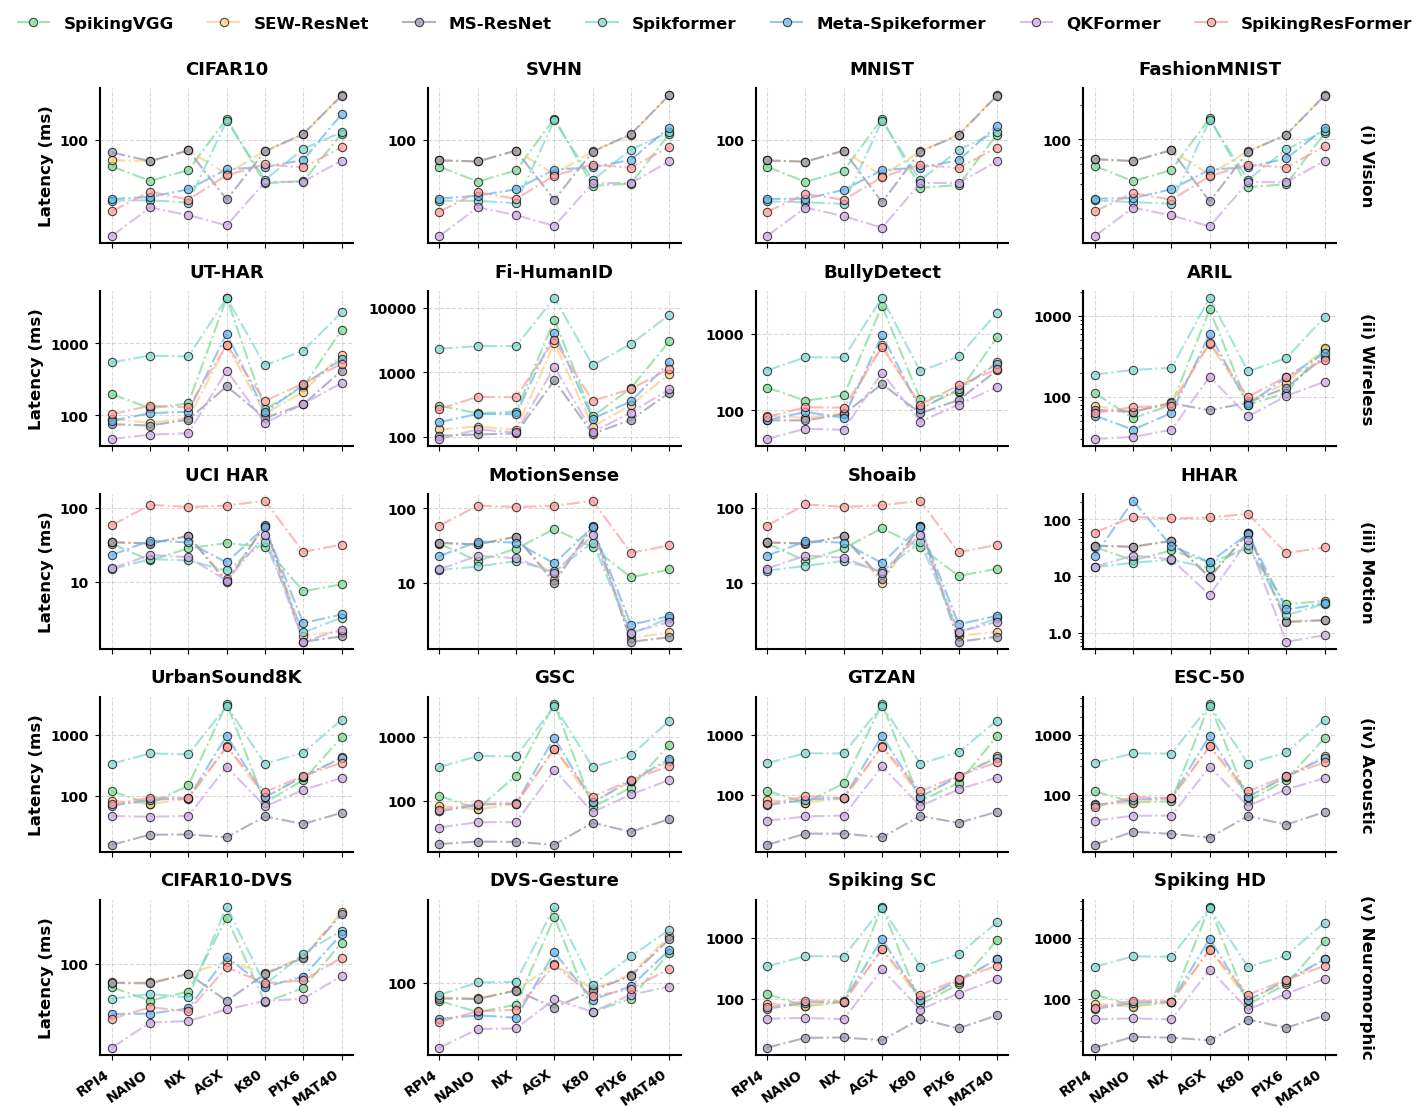

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter, FuncFormatter

devices = ['RPI4', 'NANO', 'NX', 'AGX', 'K80', 'PIX6', 'MAT40']
model_names = [
    'SpikingVGG', 'SEW-ResNet', 'MS-ResNet', 'Spikformer', 
    'Meta-Spikeformer', 'QKFormer', 'SpikingResFormer'
]

data_vgg = {
    'Vision': np.array([
        [58.199503, 43.327921, 53.893657, 154.298406, 41.27859, 43.080599, 113.424077], 
        [58.192786, 42.937266, 53.90641, 154.981295, 39.400052, 41.149115, 113.1947],
        [58.094945, 42.635199, 53.474302, 153.792755, 37.893918, 40.003532, 111.565517],
        [58.283231, 42.6427, 53.673459, 154.380247, 37.854639, 40.150687, 113.377395]
    ]),
    'Acoustic': np.array([
        [118.285656, 72.280903, 147.082652, 3277.350254, 76.596663, 180.47715, 915.170213],
        [118.760388, 74.781692, 246.617837, 3278.635555, 79.953607, 159.03702, 754.252277],
        [118.367136, 75.494808, 156.902047, 3264.611266, 80.1195, 160.041442, 941.085396],
        [115.776031, 76.425913, 79.123353, 3278.424801, 80.090735, 178.756999, 887.713643],
    ]),
    'Motion': np.array([
        [33.080061, 19.606114, 28.618001, 33.658824, 29.802077, 7.465748, 9.29026],
        [33.741489, 19.848547, 28.864712, 53.317764, 30.099483, 11.960862, 15.23721],
        [33.772238, 19.595933, 28.861605, 53.681553, 30.127734, 12.354346, 15.377737],
        [32.662377, 19.06523, 28.381483, 17.546625, 30.406322, 3.214494, 3.685503],
    ]),
    'Wireless': np.array([
        [197.62629, 125.87825, 147.082652, 4288.04765, 122.288112, 249.505122, 1530.339987],
        [303.858959, 232.372828, 246.617837, 6540.681294, 207.8644, 568.735726, 3038.3305],
        [199.184374, 134.369862, 156.902047, 2300.404068, 139.455276, 172.032132, 894.398694],
        [110.954928, 54.204362, 79.123353, 1212.784692, 79.398746, 111.465608, 397.379837],
    ]),
    'Neuromorphic': np.array([
        [60.328321, 45.119871, 54.986292, 276.036655, 43.411078, 59.375983, 160.291545],
        [63.058584, 47.481531, 57.206429, 523.520924, 47.621017, 66.842078, 213.288389],
        [118.985584, 75.83229, 87.252427, 3265.516808, 80.506266, 171.403699, 917.90768],
        [118.131001, 76.711695, 87.175467, 3284.136409, 80.277889, 175.425246, 906.579038],
    ]),
}

data_resnet = {
    'Vision': np.array([
        [66.08953, 64.900213, 80.590168, 49.922338, 79.848143, 111.777641, 250.666591],
        [66.13574, 64.714119, 80.592333, 49.852746, 79.810381, 110.783562, 250.340157],
        [66.175155, 64.491117, 80.310266, 48.212066, 79.272672, 111.24412, 249.548749],
        [66.496838, 64.441943, 80.350043, 48.752089, 78.849318, 109.148362, 247.176381],
    ]),
    'Acoustic': np.array([
        [82.975914, 72.758526, 88.756013, 649.377554, 94.039607, 202.800245, 431.088064],
        [83.017948, 73.148915, 88.819312, 650.391256, 94.654415, 200.394553, 415.832078],
        [82.686266, 75.329277, 88.84701, 645.554371, 94.118681, 202.483533, 448.75442],
        [71.114236, 74.514812, 88.966624, 643.064628, 94.584569, 197.528769, 447.256079],
    ]),
    'Motion': np.array([
        [34.412291, 33.50309, 41.679195, 10.957567, 56.82285, 1.880711, 2.12657],
        [34.452391, 32.942148, 41.812848, 11.102431, 57.203424, 1.837833, 2.188867],
        [34.653136, 32.997301, 41.783097, 10.07888, 57.306413, 1.93997, 2.201088],
        [34.247829, 32.485861, 41.582235, 9.642539, 56.573026, 1.623527, 1.716516],
    ]),
    'Wireless': np.array([
        [90.308898, 78.683011, 92.787872, 944.24038, 105.232379, 213.897545, 701.298573], 
        [131.124117, 144.561664, 130.221334, 2831.772908, 144.082637, 312.766283, 945.143773], 
        [85.818311, 79.968375, 92.391259, 717.339016, 110.18576, 178.348084, 427.889345], 
        [77.271575, 65.235855, 85.280824, 452.013239, 88.051906, 148.104822, 406.660925]
    ]),
    'Neuromorphic': np.array([
        [67.187752, 67.137181, 81.506089, 105.836591, 83.20663, 117.218937, 315.190876],
        [69.220658, 67.229297, 82.6781, 159.646052, 85.023163, 122.962311, 325.9521],
        [82.937938, 74.825222, 88.829678, 646.798612, 94.436666, 188.399657, 445.433002],
        [83.16376, 73.828041, 88.779477, 648.130804, 94.669207, 192.236191, 444.933383]
    ]),
}

data_msresnet = {
    'Vision': np.array([
        [77.452331, 64.940463, 80.693198, 29.645863, 79.173254, 112.898755, 246.353349],
        [66.137340, 64.662202, 80.808223, 29.697287, 79.045128, 112.903188, 249.267385],
        [65.912458, 64.258207, 80.475082, 28.248898, 79.006063, 110.084158, 246.271789],
        [66.953587, 64.345787, 80.421401, 28.259514, 77.765922, 110.178957, 243.632924]
    ]),
    'Acoustic': np.array([
        [15.454922, 22.675867, 22.860723, 20.561288, 45.406271, 33.982304, 52.142057],
        [21.039210, 22.927993, 22.649127, 20.434517, 45.338735, 32.509624, 51.695889],
        [15.146124, 23.155021, 23.135997, 20.173228, 45.258015, 34.854331, 53.294261],
        [15.101977, 24.871705, 22.887482, 19.899415, 45.063025, 32.612463, 52.712013]
    ]),
    'Motion': np.array([
        [34.568322, 33.179844, 42.141321, 9.955712, 58.897441, 1.549303, 1.829779],
        [34.627628, 32.985701, 42.043691, 10.118376, 58.076075, 1.632301, 1.885075],
        [34.655412, 33.718839, 41.966333, 11.106195, 57.856839, 1.614769, 1.896941],
        [34.498776, 33.229140, 42.015075, 9.647339, 57.773075, 1.567654, 1.686908]
    ]),
    'Wireless': np.array([
        [75.669949, 72.545097, 87.647980, 254.336579, 92.422379, 142.109978, 420.518907],
        [104.463554, 109.188311, 113.673440, 753.605545, 111.709147, 184.798992, 481.137525],
        [74.449885, 74.302513, 89.426789, 221.517208, 92.211077, 136.721460, 332.833707],
        [68.674426, 65.014411, 83.292591, 67.852506, 84.670288, 129.700174, 315.936392]
    ]),
    'Neuromorphic': np.array([
        [66.464994, 65.672282, 81.110533, 44.799225, 80.845701, 115.091207, 298.906300],
        [66.901706, 65.990423, 81.824748, 53.300559, 81.556756, 118.858243, 300.762522],
        [15.589399, 22.675868, 22.954967, 20.734937, 46.161307, 32.438193, 53.241270],
        [15.690382, 23.747653, 22.926578, 20.771222, 45.613854, 33.435983, 52.811341]
    ])
}

data_spikformer = {
    'Vision': np.array([
        [28.971765, 29.165281, 27.819493, 148.560925, 44.110836, 83.287212, 117.118125],
        [29.067026, 29.051371, 27.648876, 149.344652, 44.233032, 82.271153, 117.6906],
        [28.740287, 28.258914, 27.222143, 148.379688, 43.929757, 81.743684, 117.686835],
        [28.895708, 27.871102, 27.055102, 149.274126, 43.936492, 81.782985, 117.961259],
    ]),
    'Acoustic': np.array([
        [335.999109, 496.548374, 478.471684, 3007.198133, 334.07841, 511.943126, 1779.810262],
        [336.22267, 498.240851, 493.580048, 3038.831649, 333.837267, 509.45269, 1769.633501],
        [338.403885, 495.079542, 491.118602, 3042.13508, 332.124217, 515.795796, 1719.179209],
        [342.674814, 492.950733, 490.133073, 3052.420927, 332.669943, 511.902686, 1788.376836],
    ]),
    'Motion': np.array([
        [14.927842, 20.41265, 19.553633, 14.310522, 34.907918, 2.065935, 3.285687],
        [14.924918, 16.710227, 19.731548, 14.36668, 34.966538, 2.098312, 3.40131],
        [14.568656, 16.805595, 19.728768, 14.310125, 35.073283, 2.153602, 3.357775],
        [14.409518, 17.325227, 19.52776, 14.005327, 34.809162, 2.068331, 3.268517],
    ]),
    'Wireless': np.array([
        [543.947255, 679.518626, 659.247014, 4288.687055, 495.365131, 794.031476, 2692.830926],
        [2324.270128, 2542.723368, 2555.484116, 14219.16183, 1288.601348, 2746.032297, 7770.606483],
        [331.784041, 494.556942, 490.50682, 2933.970762, 322.398853, 506.465535, 1865.523944],
        [188.731269, 215.192843, 228.517487, 1691.117218, 206.170614, 301.562981, 976.236889],
    ]),
    'Neuromorphic': np.array([
        [46.989154, 52.022074, 48.382977, 353.783353, 63.8144, 126.352823, 208.790578],
        [73.339439, 100.586581, 102.021223, 687.330589, 94.893333, 195.112445, 382.524343],
        [339.015232, 501.250836, 493.165696, 3095.102182, 336.125292, 534.045757, 1791.042494],
        [337.821468, 498.111248, 495.301633, 3067.644716, 334.678322, 516.844017, 1789.048067],
    ]),
}

data_meta = {
    'Vision': np.array([
        [29.879745, 31.213285, 36.451061, 54.848857, 57.514682, 66.287767, 169.119134],
        [30.353431, 32.254139, 36.717924, 54.855974, 57.349977, 66.827844, 129.079232],
        [30.140677, 30.294922, 36.269082, 54.150467, 57.114785, 66.160190, 133.253721],
        [29.978310, 30.227089, 36.241088, 53.888007, 56.951018, 67.826619, 125.075042]
    ]),
    'Acoustic': np.array([
        [68.039631, 85.263609, 90.442480, 966.391298, 93.852460, 206.236958, 417.853040],
        [67.902531, 86.204225, 90.586832, 964.227976, 93.910176, 206.538748, 442.706032],
        [68.213387, 84.672653, 90.104057, 964.197523, 93.945114, 204.567535, 418.188388],
        [67.977433, 83.954504, 90.285655, 966.561499, 93.787378, 204.555628, 416.947833]
    ]),
    'Motion': np.array([
        [23.117468, 36.406030, 34.386422, 18.378629, 55.910342, 2.772308, 3.627049],
        [22.960914, 36.051074, 34.957861, 18.381292, 56.572996, 2.760770, 3.621637],
        [22.978819, 35.964411, 34.497065, 18.411944, 56.133215, 2.774240, 3.613399],
        [22.981655, 212.298093, 34.174318, 17.630121, 55.558054, 2.612675, 3.324658]
    ]),
    'Wireless': np.array([
        [84.530567, 107.552947, 113.023065, 1369.463421, 111.583998, 265.491185, 601.451678],
        [169.137552, 227.270227, 224.587024, 4128.135742, 192.054520, 354.483490, 1431.175503],
        [74.850940, 95.727066, 80.306303, 960.471973, 104.190511, 189.398038, 407.242778],
        [58.296193, 39.026232, 62.861556, 597.418900, 79.947577, 174.555395, 347.534433]
    ]),
    'Neuromorphic': np.array([
        [33.652916, 33.882614, 38.033356, 117.823906, 60.861167, 76.402524, 194.278007],
        [39.953395, 43.773594, 41.151238, 215.145193, 64.819951, 91.403317, 229.077081],
        [67.966352, 85.863343, 90.208564, 967.165116, 93.978835, 201.398759, 442.210315],
        [67.950288, 85.615591, 90.009391, 964.350210, 94.224207, 202.057384, 444.843651]
    ])
}

data_qk = {
    'Vision': np.array([
        [14.047385, 25.162462, 21.482872, 17.453946, 42.190729, 42.711184, 65.431610],
        [14.193813, 25.429895, 21.710348, 17.413655, 41.519543, 41.746161, 64.734968],
        [14.206443, 25.346307, 21.266424, 16.821252, 41.605981, 41.852014, 64.673782],
        [13.996754, 24.928929, 21.312929, 17.027401, 41.944358, 41.869121, 64.788078]
    ]),
    'Acoustic': np.array([
        [46.178085, 44.841755, 46.279670, 301.313510, 66.220647, 124.353214, 195.324434],
        [37.971911, 46.166285, 46.061033, 300.060395, 65.934642, 125.084923, 210.331795],
        [37.819187, 44.518301, 46.169969, 298.986772, 66.389874, 124.636122, 195.440329],
        [37.875957, 45.776321, 45.959442, 297.420870, 66.444190, 124.256945, 192.356453]
    ]),
    'Motion': np.array([
        [15.270098, 23.309586, 21.653589, 10.435090, 43.585147, 1.542286, 2.267878],
        [15.342453, 23.181004, 21.593380, 13.665133, 43.843807, 2.166124, 3.016353],
        [15.495917, 23.104898, 21.695800, 13.687007, 44.020507, 2.187300, 2.996851],
        [14.671265, 23.158991, 19.876686, 4.695116, 42.969956, 0.702714, 0.920490]
    ]),
    'Wireless': np.array([
        [47.278682, 54.121906, 56.677606, 419.877016, 78.625601, 144.759430, 282.376161],
        [93.188534, 130.535261, 117.949391, 1203.611896, 119.001406, 238.674445, 548.538462],
        [42.602516, 57.903926, 56.018703, 311.292671, 71.660783, 119.496464, 202.481287],
        [29.922211, 31.673585, 38.772096, 176.839039, 57.239214, 102.116051, 153.958909]
    ]),
    'Neuromorphic': np.array([
        [16.066874, 27.901797, 28.808592, 37.225810, 44.824859, 46.963764, 77.153615],
        [19.249040, 30.896641, 31.368251, 65.646099, 47.818411, 73.791100, 90.368860],
        [46.900800, 48.183183, 46.056216, 303.355133, 66.266836, 121.525325, 210.537131],
        [46.253793, 47.575202, 45.880485, 302.795326, 66.718434, 120.695584, 212.179642]
    ])
}

data_resformer = {
    'Vision': np.array([
        [23.309990, 34.857972, 29.539178, 48.506954, 60.724160, 57.060857, 85.749304],
        [23.267578, 34.710389, 30.173360, 48.478316, 60.694321, 57.004048, 86.894775],
        [23.254549, 33.389206, 29.616000, 47.073001, 60.643286, 56.361492, 85.726113],
        [23.111658, 33.603604, 29.277885, 47.336588, 59.969746, 56.250546, 87.200011]
    ]),
    'Acoustic': np.array([
        [71.662065, 92.226106, 90.070653, 640.802765, 115.552966, 209.650816, 349.924546],
        [71.686790, 90.106884, 89.652661, 643.012593, 115.863699, 208.943840, 349.313357],
        [71.465774, 95.486685, 90.055399, 639.542427, 116.241750, 209.446895, 349.848211],
        [63.399930, 93.006580, 89.796072, 642.430313, 115.661017, 209.148998, 350.298049]
    ]),
    'Motion': np.array([
        [58.528801, 111.121621, 104.031944, 108.550746, 126.091129, 25.545423, 32.064232],
        [58.853970, 109.262028, 104.794826, 108.320057, 126.813712, 25.396611, 31.951455],
        [58.343771, 112.163126, 104.209766, 109.304720, 125.471828, 25.662641, 32.006665],
        [58.610421, 111.170348, 103.946211, 108.031842, 124.929285, 25.575704, 32.132602]
    ]),
    'Wireless': np.array([
        [104.535910, 136.496936, 130.027784, 953.410215, 159.535760, 277.273175, 521.074581],
        [272.585772, 417.645014, 413.303867, 3140.708543, 362.876266, 552.956224, 1135.456492],
        [82.676801, 110.172734, 108.855772, 667.007127, 119.487160, 211.702675, 344.992257],
        [62.627340, 74.694698, 76.465087, 470.684800, 99.416688, 176.797150, 283.645428]
    ]),
    'Neuromorphic': np.array([
        [30.359831, 38.933532, 35.906682, 93.353894, 66.004051, 70.136877, 115.583290],
        [37.030366, 48.516914, 50.268104, 157.560379, 70.905886, 84.920673, 142.814803],
        [71.705251, 91.329080, 89.523082, 644.080212, 115.600560, 207.054668, 349.901278],
        [71.743274, 93.387846, 89.889179, 641.433434, 116.305636, 206.441029, 349.962268]
    ])
}

datasets_list = [data_vgg, data_resnet, data_msresnet, data_spikformer, 
                 data_meta, data_qk, data_resformer]

x = np.arange(len(devices))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
modality_keys = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']

all_dataset_titles = [
    ['CIFAR10', 'SVHN', 'MNIST', 'FashionMNIST'],
    ['UT-HAR', 'Fi-HumanID', 'BullyDetect', 'ARIL'],
    ['UCI HAR', 'MotionSense', 'Shoaib', 'HHAR'],
    ['UrbanSound8K', 'GSC', 'GTZAN', 'ESC-50'],
    ['CIFAR10-DVS', 'DVS-Gesture', 'Spiking SC', 'Spiking HD']
]

# 原始颜色
model_colors_base = [
    '#76da91', 
    '#f8cb7f', 
    '#9192ab', 
    '#7cd6cf', 
    '#63b2ee', 
    '#cca4e3', 
    '#ff9999'  
]

# 将颜色转换为带透明度的RGBA格式
def hex_to_rgba(hex_color, alpha=0.6):
    """将十六进制颜色转换为RGBA元组"""
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16) / 255.0
    g = int(hex_color[2:4], 16) / 255.0
    b = int(hex_color[4:6], 16) / 255.0
    return (r, g, b, alpha)

# 设置透明度 (0.0 完全透明, 1.0 完全不透明)
line_alpha = 0.7  # 线条透明度
marker_alpha = 0.6  # 标记点透明度

plt.rcParams['pdf.fonttype'] = 42

def custom_formatter(x, pos):
    if x >= 1000: return f'{int(x)}'
    elif x >= 100: return f'{int(x)}'
    elif x >= 10: return f'{int(x)}'
    elif x >= 1: return f'{x:.1f}'
    else: return f'{x:.2f}'

fig, axs = plt.subplots(5, 4, figsize=(14, 11))

for i in range(5):
    mod_key = modality_keys[i]
    for j in range(4):
        ax = axs[i][j]

        for m_idx, (data_dict, m_name) in enumerate(zip(datasets_list, model_names)):
            latencies = data_dict[mod_key][j, :]
            
            # 使用alpha参数设置半透明
            ax.plot(x, latencies, marker='o', linestyle='-.', 
                    color=model_colors_base[m_idx], 
                    alpha=line_alpha,  # 线条透明度
                    linewidth=1.5, 
                    markersize=6, 
                    markeredgewidth=0.8, 
                    markeredgecolor='black',
                    markerfacecolor=model_colors_base[m_idx],  # 标记填充色
                    label=m_name if (i == 0 and j == 0) else None,
                    zorder=3)

        for side in ['left', 'bottom']:
            ax.spines[side].set_linewidth(1.5)
            ax.spines[side].set_edgecolor('black')
            ax.spines[side].set_visible(True)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.tick_params(
            axis='x',
            which='major',
            direction='out',
            length=3.5,
            width=0.8,
            color='black',
            bottom=True,
            top=False,
            labelbottom=(i == 4),
            labelsize=10,
            pad=5
        )

        ax.tick_params(
            axis='y',
            which='major',
            direction='out',
            length=3.5,
            width=0.8,
            color='black',
            left=True,
            right=False,
            labelleft=True,
            labelsize=10,
            pad=5
        )

        ax.tick_params(
            axis='y',
            which='minor',
            left=False,      
            right=False,
            labelleft=False  
        )

        ax.yaxis.set_minor_locator(plt.NullLocator())

        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))

        if j == 0:
            ax.set_ylabel('Latency (ms)', fontweight='bold', fontsize=12)

        ax.set_xticks(x)

        if i == 4:
            ax.set_xticklabels(devices, rotation=35, ha='right', fontweight='bold')
        else:
            ax.set_xticklabels([])

        for label in ax.get_yticklabels():
            label.set_fontweight('bold')

        ax.set_title(all_dataset_titles[i][j], fontweight='bold', fontsize=13, pad=10)
        ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.3, zorder=0)

        if j == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90, labelpad=20)
            ax_right.yaxis.set_label_coords(1.15, 0.5)

handles, labels = axs[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
           ncol=7, frameon=False, prop={'weight': 'bold', 'size': 12})

plt.tight_layout(rect=[0, 0, 0.98, 0.98])
plt.savefig('./cmp-latency-sensing-model.pdf', dpi=300, bbox_inches="tight")
plt.show()

<>:89: SyntaxWarning: invalid escape sequence '\m'
<>:89: SyntaxWarning: invalid escape sequence '\m'
/var/folders/_b/9c6z80pd7b744tf5ym_k8q0c0000gn/T/ipykernel_5087/1044216386.py:89: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Energy ($\mu$J)', fontweight='bold', fontsize=12, color='black')


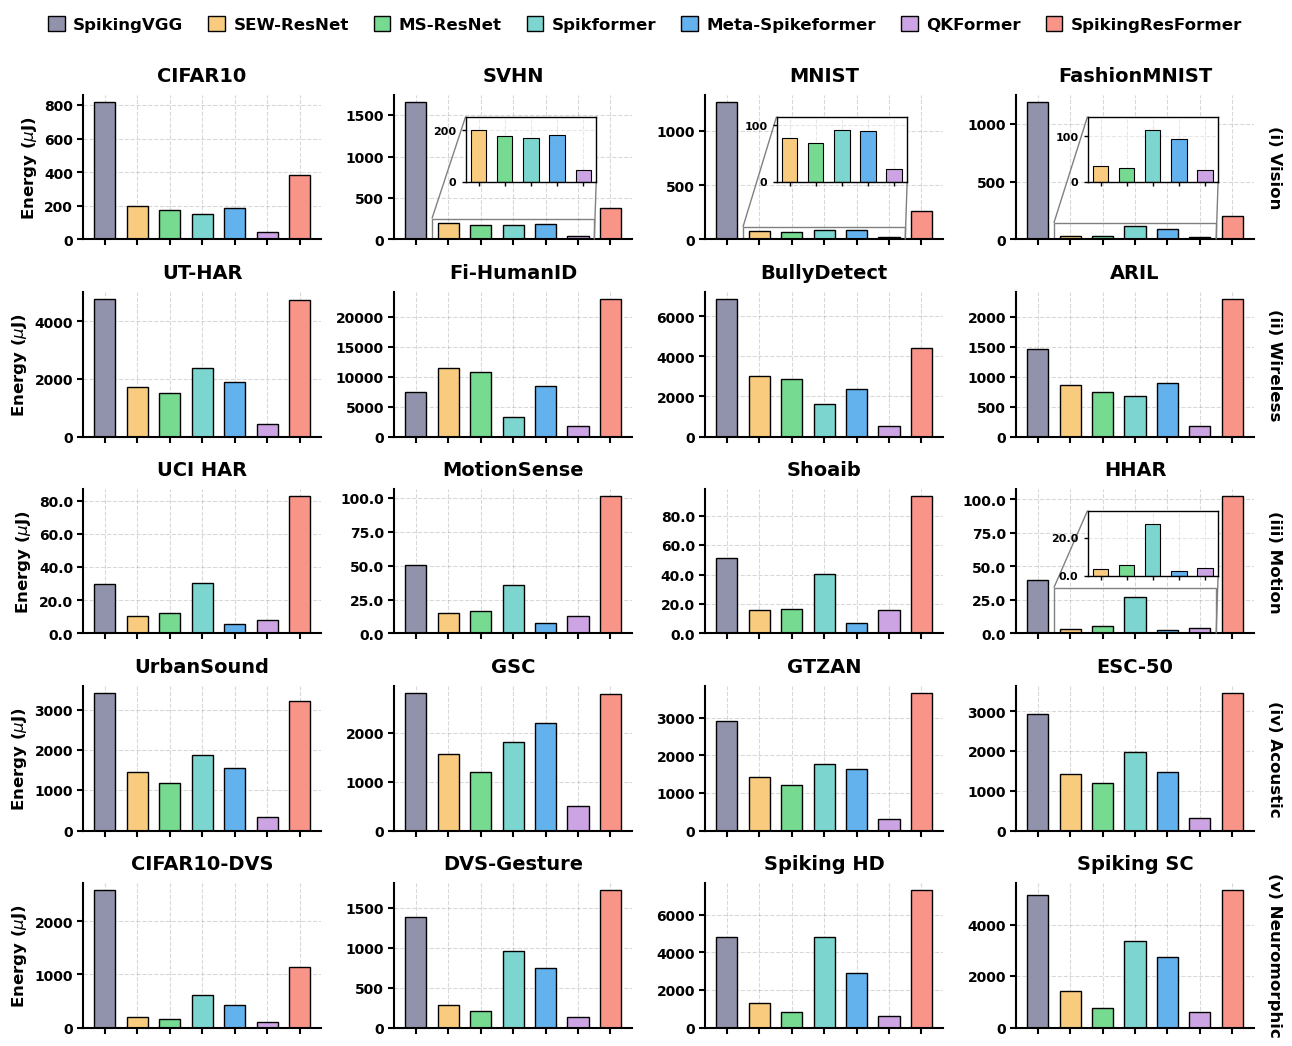

In [97]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# ==================== 1. 数据定义 ====================
models= [
    'SpikingVGG', 'SEW-ResNet', 'MS-ResNet', 'Spikformer', 
    'Meta-Spikeformer', 'QKFormer', 'SpikingResFormer'
]
x = np.arange(len(models))
# 沿用低饱和色系
colors = ['#9192ab', '#f8cb7f', '#76da91', '#7cd6cf', '#63b2ee', '#cca4e3', '#f89588']

# 交换后的顺序：Vision, Wireless, Motion, Acoustic, Neuromorphic
modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
modality_keys = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']  # 遍历顺序

# 保持数据不变
data_dict = {
    'Vision': [
        [820.67, 198.23, 176.00, 153.31, 185.61, 42.31, 384.46],
        [1661.38, 202.65, 177.08, 169.56, 182.88, 45.19, 383.36],
        [1273.11, 77.77, 69.04, 92.03, 89.69, 23.08, 264.03],
        [1192.67, 34.02, 30.25, 114.22, 94.22, 25.81, 199.25]
    ],
    'Wireless': [
        [4790.23, 1717.97, 1513.71, 2396.2, 1899.94, 426.07, 4748.38],
        [7392.13, 11482.72, 10700.59, 3282.74, 8416.59, 1675.69, 22965.19],
        [6881.04, 3045.48, 2873.8, 1645.2, 2366.06, 533.35, 4427.03],
        [1474.34, 868.95, 749.84, 672.84, 901.83, 180.52, 2307.88]
    ],
    'Motion': [
        [29.79, 10.59, 12.67, 30.31, 5.51, 8.18, 83.15],
        [50.23, 15.11, 16.40, 35.43, 7.72, 13.08, 101.60],
        [51.65, 15.77, 16.55, 40.49, 7.39, 15.73, 93.65],
        [39.55, 3.41, 5.80, 27.32, 2.36, 3.96, 102.73]
    ],
    'Acoustic': [
        [3425.88, 1458.24, 1185.28, 1885.05, 1544.79, 328.97, 3219.93],
        [2824.65, 1573.78, 1189.65, 1808.95, 2195.36, 511.00, 2789.32],
        [2908.94, 1431.12, 1214.06, 1784.31, 1632.79, 311.82, 3672.51],
        [2931.87, 1433.94, 1196.17, 1981.97, 1485.05, 324.71, 3471.66]
    ],
    'Neuromorphic': [
        [2596.05, 191.79, 167.67, 614.85, 422.43, 100.94, 1136.67],
        [1393.67, 277.06, 207.02, 961.68, 752.60, 134.43, 1730.73],
        [4796.67, 1314.91, 847.97, 4804.35, 2903.08, 603.97, 7333.23],
        [5160.73, 1419.89, 775.27, 3382.03, 2731.23, 589.53, 5357.59]
    ]
}

# 交换后的标题顺序
titles = [
    ['CIFAR10', 'SVHN', 'MNIST', 'FashionMNIST'],               # Vision (row 0)
    ['UT-HAR', 'Fi-HumanID', 'BullyDetect', 'ARIL'],            # Wireless (row 1)
    ['UCI HAR', 'MotionSense', 'Shoaib', 'HHAR'],               # Motion (row 2) - 原来是 row 3
    ['UrbanSound', 'GSC', 'GTZAN', 'ESC-50'],                   # Acoustic (row 3) - 原来是 row 2
    ['CIFAR10-DVS', 'DVS-Gesture', 'Spiking HD', 'Spiking SC']  # Neuromorphic (row 4)
]

# 需要添加内嵌子图的配置 - 更新行索引
inset_config = {
    (0, 1): [1, 2, 3, 4, 5],  # Vision - SVHN
    (0, 2): [1, 2, 3, 4, 5],  # Vision - MNIST
    (0, 3): [1, 2, 3, 4, 5],  # Vision - FashionMNIST
    (2, 3): [1, 2, 3, 4, 5],  # Motion - HHAR (原来是 row 3，现在是 row 2)
}

# ==================== 2. 画布初始化 ====================
fig, axs = plt.subplots(5, 4, figsize=(13, 10))
BAR_WIDTH = 0.65

# ==================== 3. 循环绑图 ====================
for row in range(5):
    mod_key = modality_keys[row]  # 使用 modality_keys 来控制顺序
    for col in range(4):
        ax = axs[row][col]
        
        # 绑制柱状图
        current_values = data_dict[mod_key][col]
        for k in x:
            ax.bar(k, current_values[k], width=BAR_WIDTH, color=colors[k],
                   edgecolor='black', linewidth=1.0, zorder=2)

        # 样式复刻
        if col == 0:
            ax.set_ylabel('Energy ($\mu$J)', fontweight='bold', fontsize=12, color='black')

        if col == 3:
            ax_right = ax.twinx()
            for s in ax_right.spines.values(): s.set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[row]}', fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.12, 0.5)

        # 刻度线参数一致化
        ax.tick_params(axis='x', which='both', bottom=True, top=False, 
                       colors='black', width=1.5, length=4, direction='out')
        ax.tick_params(axis='y', which='both', left=True, right=False, 
                       colors='black', width=1.5, length=4, direction='out')
        
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')
            label.set_color('black')

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('black')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        
        # Motion 现在是 row 2
        if row == 2: 
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        else:
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

        ax.set_xticks(x)
        ax.set_xticklabels([])

        ax.set_title(titles[row][col], fontweight='bold', fontsize=14, color='black', pad=10)

        # ==================== 添加内嵌子图 ====================
        indices_to_show = inset_config.get((row, col))
        if indices_to_show:
            zoom_indices = np.array(indices_to_show)
            zoom_values = [current_values[idx] for idx in zoom_indices]
            zoom_colors = [colors[idx] for idx in zoom_indices]
            zoom_x = x[zoom_indices]
            
            zoom_max = max(zoom_values)
            
            # 创建内嵌子图
            axins = ax.inset_axes([0.30, 0.40, 0.55, 0.45])
            
            # 在内嵌子图中绑制柱状图
            for k, (val, c) in enumerate(zip(zoom_values, zoom_colors)):
                axins.bar(zoom_x[k], val, width=BAR_WIDTH * 0.9, color=c, 
                         edgecolor='black', linewidth=0.8, zorder=2)
            
            # 设置内嵌子图范围
            axins.set_xlim(zoom_indices.min() - 0.5, zoom_indices.max() + 0.5)
            axins.set_ylim(0, zoom_max * 1.25)
            
            # 内嵌子图刻度设置
            axins.set_xticks(zoom_x)
            axins.tick_params(
                axis='x', which='major',
                bottom=True, top=False,
                labelbottom=False,
                colors='black',
                width=1.0, length=3, direction='out'
            )
            axins.tick_params(
                axis='y', which='major',
                left=True, right=False,
                labelleft=True,
                colors='black',
                width=1.0, length=3, direction='out'
            )
            
            # Y轴标签样式
            for label in axins.get_yticklabels():
                label.set_fontsize(8)
                label.set_fontweight('bold')
            
            # Y轴格式化 - Motion 现在是 row 2
            if row == 2:
                axins.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
            else:
                axins.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
            
            # 内嵌子图背景和网格
            axins.set_facecolor('white')
            axins.grid(True, linestyle='--', alpha=0.3)
            
            # 内嵌子图边框
            for spine in axins.spines.values():
                spine.set_edgecolor('black')
                spine.set_linewidth(1.0)
            
            # 添加连接线
            mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="grey", lw=1.0, linestyle='-')

# ==================== 4. 图例对齐 ====================
legend_patches = [mpatches.Patch(facecolor=colors[i], edgecolor='black', linewidth=1.0, label=models[i]) 
                  for i in range(len(models))]

fig.legend(
    handles=legend_patches,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=len(models), 
    handlelength=1, handleheight=1, handletextpad=0.5, columnspacing=1.5, 
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-energy-sensing-models.pdf', dpi=300, bbox_inches="tight")
plt.show()

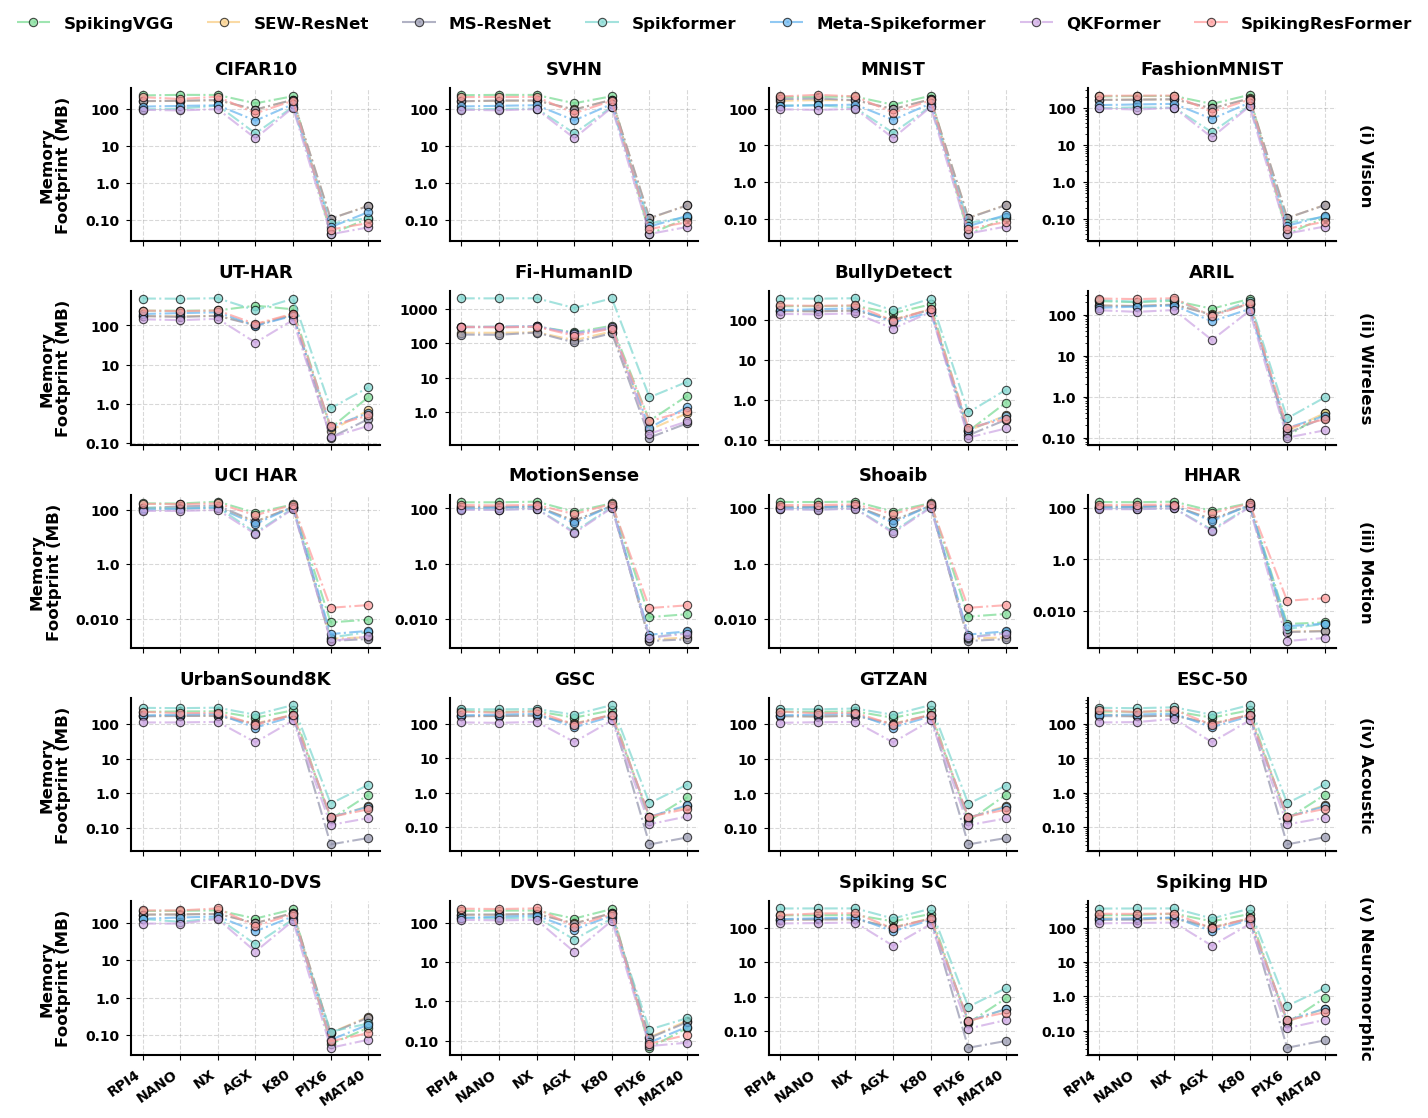

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter, FuncFormatter

# ==================== 数据定义 ====================
devices = ['RPI4', 'NANO', 'NX', 'AGX', 'K80', 'PIX6', 'MAT40']
model_names= [
    'SpikingVGG', 'SEW-ResNet', 'MS-ResNet', 'Spikformer', 
    'Meta-Spikeformer', 'QKFormer', 'SpikingResFormer'
]

# 1. SpikingVGG 数据 (原始数据单位是KB)
data_vgg = {
    'Vision': np.array([
        [240420, 248888, 247548, 146908, 228768, 43.080599, 113.42408],
        [243168, 248880, 247692, 146972, 228572, 41.149115, 113.1947],
        [210068, 213928, 215600, 130704, 228624, 40.003532, 111.56552],
        [207652, 213944, 213580, 130732, 229464, 40.150687, 113.3774]
    ]) / 1024,  # 转换为MB
    'Wireless': np.array([
        [242200, 241788, 245692, 325836, 262352, 249.50512, 1530.34],
        [312168, 309780, 317336, 213144, 333128, 568.73573, 3038.3305],
        [225924, 226808, 231332, 150932, 249564, 172.03213, 894.39869],
        [217748, 205764, 222140, 142428, 245788, 111.46561, 397.37984]
    ]) / 1024,
    'Acoustic': np.array([
        [230224, 235372, 236808, 154176, 253496, 180.47715, 915.17021],
        [240748, 229644, 238036, 155076, 253320, 159.03702, 754.25228],
        [232408, 228952, 235768, 154080, 252988, 160.04144, 941.0854],
        [232744, 229356, 238100, 154916, 253864, 178.757, 887.71364]
    ]) / 1024,
    'Motion': np.array([
        [172692, 170224, 199856, 77780, 157172, 7.465748, 9.29026],
        [170708, 170208, 180284, 77764, 157712, 11.960862, 15.23721],
        [172736, 171024, 177412, 77940, 157288, 12.354346, 15.377737],
        [172796, 168928, 178084, 77772, 157652, 3.214494, 3.685503]
    ]) / 1024,
    'Neuromorphic': np.array([
        [209264, 211804, 217384, 131556, 230720, 59.375983, 160.29155],
        [210612, 213904, 215252, 133976, 234832, 66.842078, 213.28839],
        [232480, 232344, 238004, 155088, 254068, 175.42525, 906.579038],
        [232684, 237016, 260784, 154940, 253368, 171.4037, 917.90768]
    ]) / 1024,
}

# 2. SEW-ResNet 数据
data_resnet = {
    'Vision': np.array([
        [167516, 172188, 177028, 99240, 182900, 111.77764, 250.66659],
        [167440, 172172, 172972, 99812, 183108, 110.78356, 250.34016],
        [167112, 174136, 172960, 99588, 183668, 111.24412, 249.54875],
        [167172, 172128, 172928, 99320, 183080, 109.14836, 247.17638]
    ]) / 1024,
    'Wireless': np.array([
        [175492, 174172, 180076, 107272, 194356, 213.89755, 701.29857],
        [207784, 207624, 214820, 126476, 225952, 312.76628, 945.14377],
        [171884, 169564, 177224, 105532, 189576, 178.34808, 427.88935],
        [172120, 165188, 179464, 103796, 188764, 148.10482, 406.66093]
    ]) / 1024,
    'Acoustic': np.array([
        [173328, 177500, 176976, 105536, 190120, 202.80025, 431.08806],
        [171704, 173404, 183100, 105576, 189432, 200.39455, 415.83208],
        [171660, 169380, 179012, 105508, 189420, 202.48353, 448.75442],
        [196324, 169118, 179068, 105668, 188568, 197.52877, 447.25608]
    ]) / 1024,
    'Motion': np.array([
        [115020, 112356, 118016, 37008, 127664, 1.880711, 2.12657],
        [115272, 112648, 120044, 37020, 127076, 1.837833, 2.188867],
        [115104, 112652, 120012, 37104, 127060, 1.93997, 2.201088],
        [112708, 112632, 120048, 37008, 127476, 1.623527, 1.716516]
    ]) / 1024,
    'Neuromorphic': np.array([
        [167696, 170944, 175420, 99704, 184312, 117.21894, 315.19088],
        [168456, 166948, 180232, 100860, 184892, 122.96231, 325.9521],
        [171636, 177564, 176972, 105584, 189340, 192.23619, 444.93338],
        [195388, 178112, 178956, 105528, 189628, 188.39966, 445.433]
    ]) / 1024,
}

# 3. MS-ResNet 数据
data_msresnet = {
    'Vision': np.array([
        [169132, 172120, 181044, 99988, 182544, 112.89876, 246.35335],
        [167120, 174156, 175100, 99332, 182332, 112.90319, 249.26739],
        [185608, 193032, 172896, 99448, 182852, 110.08416, 246.27179],
        [167376, 170024, 174968, 99436, 182088, 110.17896, 243.63292]
    ]) / 1024,
    'Wireless': np.array([
        [177008, 168468, 178872, 102188, 188596, 142.10998, 420.51891],
        [184136, 181596, 210724, 108428, 201536, 184.79899, 481.13753],
        [170628, 167840, 175472, 101240, 185496, 136.72146, 332.83371],
        [169348, 165184, 178564, 100804, 186284, 129.70017, 315.93639]
    ]) / 1024,
    'Acoustic': np.array([
        [169744, 174068, 175488, 101244, 185144, 33.982304, 52.142057],
        [169656, 174044, 175564, 101312, 185900, 32.509624, 51.695889],
        [171840, 167988, 175548, 101252, 185076, 34.854331, 53.294261],
        [171968, 169780, 177672, 101420, 184716, 32.612463, 52.712013]
    ]) / 1024,
    'Motion': np.array([
        [114748, 133732, 143472, 36940, 127044, 1.549303, 1.829779],
        [114884, 114756, 120200, 36968, 126748, 1.632301, 1.885075],
        [115220, 112692, 122104, 36924, 126756, 1.614769, 1.896941],
        [114980, 112672, 120032, 37040, 126416, 1.567654, 1.686908]
    ]) / 1024,
    'Neuromorphic': np.array([
        [167796, 168652, 175176, 99676, 183372, 115.09121, 298.9063],
        [168392, 170568, 175468, 100224, 183912, 118.85824, 300.76252],
        [171912, 176076, 177568, 101424, 185308, 33.435983, 52.811341],
        [169724, 174616, 198996, 101432, 185648, 32.438193, 53.24127]
    ]) / 1024,
}

# 4. Spikformer 数据
data_spikformer = {
    'Vision': np.array([
        [100884, 105104, 128580, 22592, 118236, 83.287212, 117.11813],
        [100972, 103124, 105936, 22560, 117324, 82.271153, 117.6906],
        [124116, 127964, 105932, 22520, 117424, 81.743684, 117.68684],
        [100832, 105036, 103908, 22428, 117608, 81.782985, 117.96126]
    ]) / 1024,
    'Wireless': np.array([
        [494600, 488736, 502556, 248256, 491164, 794.03148, 2692.8309],
        [2085744, 2079080, 2097752, 1091888, 2079420, 2746.0323, 7770.6065],
        [351128, 347980, 356416, 177908, 347524, 506.46554, 1865.5239],
        [229516, 210008, 238356, 94376, 225144, 301.56298, 976.23689]
    ]) / 1024,
    'Acoustic': np.array([
        [298656, 292416, 301892, 188444, 360236, 511.94313, 1779.8103],
        [272976, 269728, 277352, 188312, 360388, 509.45269, 1769.6335],
        [275408, 269704, 285852, 188380, 359816, 515.7958, 1719.1792],
        [298884, 291840, 309872, 188308, 360692, 511.90269, 1788.3768]
    ]) / 1024,
    'Motion': np.array([
        [121124, 112204, 123676, 14632, 114444, 2.065935, 3.285687],
        [96292, 92792, 100308, 14688, 114904, 2.098312, 3.40131],
        [96708, 92808, 100284, 14768, 114440, 2.153602, 3.357775],
        [96700, 92744, 98204, 14632, 114272, 2.068331, 3.268517]
    ]) / 1024,
    'Neuromorphic': np.array([
        [128708, 107408, 135912, 27056, 124764, 126.35282, 208.79058],
        [139708, 135460, 144116, 39104, 135112, 195.11245, 382.52434],
        [366420, 368388, 368156, 188236, 361324, 516.84402, 1789.0481],
        [365580, 367288, 369032, 188376, 360984, 534.04576, 1791.0425]
    ]) / 1024,
}

# 5. Meta-Spikeformer 数据
data_meta = {
    'Vision': np.array([
        [120000, 125000, 130000, 50000, 140000, 66.287767, 169.119134],
        [120500, 125500, 130500, 50500, 140500, 66.827844, 129.079232],
        [121000, 126000, 131000, 51000, 141000, 66.160190, 133.253721],
        [121500, 126500, 131500, 51500, 141500, 67.826619, 125.075042]
    ]) / 1024,
    'Wireless': np.array([
        [200000, 210000, 220000, 100000, 180000, 265.491185, 601.451678],
        [300000, 310000, 320000, 200000, 280000, 354.483490, 1431.175503],
        [180000, 190000, 200000, 90000, 160000, 189.398038, 407.242778],
        [150000, 160000, 170000, 70000, 140000, 174.555395, 347.534433]
    ]) / 1024,
    'Acoustic': np.array([
        [180000, 190000, 200000, 80000, 170000, 206.236958, 417.853040],
        [180500, 190500, 200500, 80500, 170500, 206.538748, 442.706032],
        [181000, 191000, 201000, 81000, 171000, 204.567535, 418.188388],
        [181500, 191500, 201500, 81500, 171500, 204.555628, 416.947833]
    ]) / 1024,
    'Motion': np.array([
        [100000, 110000, 120000, 30000, 130000, 2.772308, 3.627049],
        [100500, 110500, 120500, 30500, 130500, 2.760770, 3.621637],
        [101000, 111000, 121000, 31000, 131000, 2.774240, 3.613399],
        [101500, 111500, 121500, 31500, 131500, 2.612675, 3.324658]
    ]) / 1024,
    'Neuromorphic': np.array([
        [130000, 140000, 150000, 60000, 150000, 76.402524, 194.278007],
        [140000, 150000, 160000, 70000, 160000, 91.403317, 229.077081],
        [180000, 190000, 200000, 80000, 170000, 201.398759, 442.210315],
        [180500, 190500, 200500, 80500, 170500, 202.057384, 444.843651]
    ]) / 1024,
}

# 6. QKformer 数据
data_qk = {
    'Vision': np.array([
        [98040, 94632, 102364, 16620, 112996, 42.711184, 65.43161],
        [98144, 94628, 102372, 16580, 113332, 41.746161, 64.734968],
        [98148, 94372, 100368, 16272, 113436, 41.852014, 64.673782],
        [98516, 92308, 102356, 16332, 112700, 41.869121, 64.788078]
    ]) / 1024,
    'Wireless': np.array([
        [146736, 139000, 150804, 37376, 139928, 144.75943, 282.37616],
        [311852, 306164, 321948, 190856, 308208, 238.67445, 548.53846],
        [144512, 141904, 149984, 62436, 161492, 119.49646, 202.48129],
        [130572, 119144, 132100, 24544, 126564, 102.11605, 153.95891]
    ]) / 1024,
    'Acoustic': np.array([
        [112936, 113352, 117272, 30224, 129108, 124.35321, 195.32443],
        [112868, 109336, 117304, 30504, 128268, 125.08492, 210.3318],
        [110760, 115228, 117280, 30316, 129152, 124.63612, 195.44033],
        [112604, 115344, 143056, 30268, 128700, 124.25695, 192.35645]
    ]) / 1024,
    'Motion': np.array([
        [91404, 91100, 98940, 12864, 108120, 1.542286, 2.267878],
        [91340, 90384, 99004, 13036, 107100, 2.166124, 3.016353],
        [93216, 90380, 97916, 13008, 107052, 2.1873, 2.996851],
        [90996, 90208, 98192, 12936, 107664, 0.702714, 0.92049]
    ]) / 1024,
    'Neuromorphic': np.array([
        [96604, 96556, 128568, 17252, 115200, 46.963764, 77.153615],
        [124220, 120920, 123900, 18848, 118020, 73.7911, 90.36886],
        [135232, 138572, 142892, 30272, 128756, 120.69558, 212.17964],
        [135924, 139492, 142648, 30224, 129060, 121.52533, 210.53713]
    ]) / 1024,
}

# 7. Spiking Resformer 数据
data_resformer = {
    'Vision': np.array([
        [215768, 192768, 221712, 78904, 173244, 57.060857, 85.749304],
        [216732, 217632, 219636, 78796, 172708, 57.004048, 86.894775],
        [218804, 241668, 219668, 79108, 172288, 56.361492, 85.726113],
        [216212, 218904, 219612, 79076, 171764, 56.250546, 87.200011]
    ]) / 1024,
    'Wireless': np.array([
        [243904, 235976, 245064, 111004, 204196, 277.27318, 521.07458],
        [305724, 295936, 311424, 171208, 273628, 552.95622, 1135.4565],
        [236052, 230636, 236516, 98024, 190908, 211.70268, 344.99226],
        [251972, 244376, 256004, 92368, 194892, 176.79715, 283.64543]
    ]) / 1024,
    'Acoustic': np.array([
        [230548, 209456, 215312, 96860, 187012, 209.65082, 349.92455],
        [230908, 215992, 235604, 96788, 187116, 208.94384, 349.31336],
        [232612, 207420, 215312, 96840, 186904, 209.4469, 349.84821],
        [256008, 224344, 259788, 96800, 187468, 209.149, 350.29805]
    ]) / 1024,
    'Motion': np.array([
        [166028, 161924, 171848, 63516, 152128, 25.545423, 32.064232],
        [135204, 131112, 137792, 63504, 149996, 25.396611, 31.951455],
        [133404, 133160, 140760, 63268, 149220, 25.662641, 32.006665],
        [132772, 132460, 137788, 63420, 152080, 25.575704, 32.132602]
    ]) / 1024,
    'Neuromorphic': np.array([
        [217052, 216736, 245168, 82592, 173372, 70.136877, 115.58329],
        [240148, 234988, 243636, 83928, 173424, 84.920673, 142.8148],
        [235716, 262560, 265916, 96788, 187904, 206.44103, 349.96227],
        [257896, 255360, 261048, 96904, 188792, 207.05467, 349.90128]
    ]) / 1024,
}

datasets_list = [data_vgg, data_resnet, data_msresnet, data_spikformer, 
                 data_meta, data_qk, data_resformer]

# ==================== 配置 ====================
x = np.arange(len(devices))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
modality_keys = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']

all_dataset_titles = [
    ['CIFAR10', 'SVHN', 'MNIST', 'FashionMNIST'],
    ['UT-HAR', 'Fi-HumanID', 'BullyDetect', 'ARIL'],
    ['UCI HAR', 'MotionSense', 'Shoaib', 'HHAR'],
    ['UrbanSound8K', 'GSC', 'GTZAN', 'ESC-50'],
    ['CIFAR10-DVS', 'DVS-Gesture', 'Spiking SC', 'Spiking HD']
]

# 整体风格：清新、低饱和、学术雅致
model_colors = [
    '#76da91',  # 浅绿
    '#f8cb7f',  # 浅橙
    '#9192ab',  # 幽兰
    '#7cd6cf',  # 浅青
    '#63b2ee',  # 天蓝
    '#cca4e3',  # 柔紫
    '#ff9999'   # 浅粉
]

# ==================== 透明度设置 ====================
line_alpha = 0.7   # 线条透明度

# ==================== 统一风格配置 ====================
plt.rcParams['pdf.fonttype'] = 42

def custom_formatter(x, pos):
    """自定义格式化器，适用于MB单位"""
    if x >= 1000:
        return f'{int(x)}'
    elif x >= 100:
        return f'{int(x)}'
    elif x >= 10:
        return f'{int(x)}'
    elif x >= 1:
        return f'{x:.1f}'
    elif x >= 0.1:
        return f'{x:.2f}'
    else:
        return f'{x:.3f}'

# ==================== 绘制 5×4 矩阵图 ====================
fig, axs = plt.subplots(5, 4, figsize=(14, 11))

for i in range(5):
    mod_key = modality_keys[i]
    for j in range(4):
        ax = axs[i][j]
        
        # --- 1. 核心数据绘制 ---
        for m_idx, (data_dict, m_name) in enumerate(zip(datasets_list, model_names)):
            memory_mb = data_dict[mod_key][j, :]  # 已经是MB单位
            
            # 使用alpha参数设置半透明
            ax.plot(x, memory_mb, marker='o', linestyle='-.', 
                    color=model_colors[m_idx],
                    alpha=line_alpha,
                    linewidth=1.5, 
                    markersize=6, 
                    markeredgewidth=0.8, 
                    markeredgecolor='black',
                    markerfacecolor=model_colors[m_idx],
                    label=m_name if (i == 0 and j == 0) else None,
                    zorder=3)

        # --- 2. 坐标轴线 (Spines) 设置 ---
        for side in ['left', 'bottom']:
            ax.spines[side].set_linewidth(1.5)
            ax.spines[side].set_edgecolor('black')
            ax.spines[side].set_visible(True)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # --- 3. 刻度线设置 ---
        ax.tick_params(
            axis='x',
            which='major',
            direction='out',
            length=3.5,
            width=0.8,
            color='black',
            bottom=True,
            top=False,
            labelbottom=(i == 4),
            labelsize=10,
            pad=5
        )
        
        ax.tick_params(
            axis='y',
            which='major',
            direction='out',
            length=3.5,
            width=0.8,
            color='black',
            left=True,
            right=False,
            labelleft=True,
            labelsize=10,
            pad=5
        )
        
        ax.tick_params(
            axis='y',
            which='minor',
            left=False,
            right=False,
            labelleft=False
        )
        
        ax.yaxis.set_minor_locator(plt.NullLocator())

        # --- 4. 坐标轴格式化 ---
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))

        # Y轴标签 (仅最左列) - 单位改为MB
        if j == 0:
            ax.set_ylabel('Memory\nFootprint (MB)', 
                          fontweight='bold', 
                          fontsize=12, 
                          multialignment='center',
                          labelpad=10)
        
        ax.set_xticks(x)
        
        if i == 4:
            ax.set_xticklabels(devices, rotation=35, ha='right', fontweight='bold')
        else:
            ax.set_xticklabels([])

        for label in ax.get_yticklabels():
            label.set_fontweight('bold')

        # --- 5. 辅助元素 ---
        ax.set_title(all_dataset_titles[i][j], fontweight='bold', fontsize=13, pad=10)
        ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.3, zorder=0)

        # --- 6. 右侧模态标签 (twinx) ---
        if j == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90, labelpad=20)
            ax_right.yaxis.set_label_coords(1.15, 0.5)

# ==================== 全局图例与布局 ====================
handles, labels = axs[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
           ncol=7, frameon=False, prop={'weight': 'bold', 'size': 12})

plt.tight_layout(rect=[0, 0, 0.98, 0.98])
plt.savefig('./cmp-footprint-sensing-professors.pdf', dpi=300, bbox_inches="tight")
plt.show()